In [1]:
#!jt -t onedork -fs 12 -tfs 12 -nfs 15 -cellw 95% -T

In [2]:
#!jt -r

In [3]:
"""
-t monokai → theme name (onedork grade3 oceans16 chesterish monokai solarizedl solarizedd)

-fs 11 → code font size

-tfs 11 → text font size

-nfs 11 → notebook name font size

-cellw 95% → wider notebook cells
"""

'\n-t monokai → theme name (onedork grade3 oceans16 chesterish monokai solarizedl solarizedd)\n\n-fs 11 → code font size\n\n-tfs 11 → text font size\n\n-nfs 11 → notebook name font size\n\n-cellw 95% → wider notebook cells\n'

In [1]:
#To Detect the environment : OSC or Jupyter NB PC
import os
import socket
import sys  
os.makedirs("logs", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("models_checkpoint", exist_ok=True)

def detect_environment():
    hostname = socket.gethostname().lower()
    if "pitzer" in hostname or "osc" in hostname:
        return "osc"
    elif os.name == "nt":  # Windows (your PC)
        if "ipykernel" in sys.modules:
            return "jupyter_local"
        else:
            return "anaconda_prompt"
                
    elif "colab" in hostname:
        return "colab"
    else:
        return "unknown"

ENV = detect_environment()
print(f"Running environment detected: {ENV}")

Running environment detected: jupyter_local


In [2]:
version_ = "Stealthy_AE_WCGAN_V2"

if ENV == "jupyter_local":
    experiment_tag = version_

elif ENV == "osc" or ENV == "anaconda_prompt":
    version = version_

In [3]:
#*** 
if ENV == "osc" or ENV == "anaconda_prompt":
    import argparse

    # ---------------- Argument Parser ---------------- #
    parser = argparse.ArgumentParser(description="Train RCGAN with custom hyperparameters")
    
    parser.add_argument("--seq_length", type=int, default=50, help="Sequence length for LSTM")
    parser.add_argument("--latent_dim", type=int, default=7, help="Latent noise dimension")
    parser.add_argument("--hidden_dim", type=int, default=128, help="Hidden dimension for LSTM layers")
    parser.add_argument("--batch_size", type=int, default=64, help="Batch size")
    parser.add_argument("--dwn_smple", type=int, default=5, help="downsample factor for data")
    parser.add_argument("--n_epochs", type=int, default=200, help="Number of training epochs")

    args = parser.parse_args()

    # ------------- Assign to variables -------------- #
    seq_length = args.seq_length
    latent_dim = args.latent_dim
    hidden_dim = args.hidden_dim
    batch_size = args.batch_size
    n_epochs   = args.n_epochs
    downsample_factor = args.dwn_smple
    #experiment_tag = f"{version}_seq{seq_length}_z{latent_dim}_h{hidden_dim}_b{batch_size}_e{n_epochs}_dwn{downsample_factor}"
    experiment_tag = f"{version}"
    
#python stealthy_attack_model_transformer_ver1.py --ENCODER_LENGTH 60 --DECODER_LENGTH 20 --BATCH_SIZE 64 --NUM_WORKERS 4 --stride_len 10 --d_model 128 --hidden_size 128 --n_heads 4 --dropout 0.1 --lr 1e-3 --downsample_factor 100 --max_epochs 50

elif ENV == "jupyter_local":
    seq_length = 50                    # Sequence length for LSTM
    latent_dim = 1                    # dimension of random noise vector (increased for richer generation)
    hidden_dim = 128                   # LSTM hidden units (increased for more representational power)
    batch_size = 32                    # balanced batch size for stable training
    n_epochs = 30                     # train longer to allow adversarial convergence
    downsample_factor = 1              # downsample factor for data
    λ_l1 = 10.0                       # adjust as needed (typically 5–20) alignment with the true physical signal (y_real)
    λ_tv = 1.0                        # start small, e.g. 0.5–2.0  temporal smoothness (y_t ≈ y_{t-1})
    
lr = 1e-3  # Learning Rate
dropout = 0.1

In [7]:
"""
# ----------------- Hyperparameters ------------------ #
seq_length = 50                    # Sequence length for LSTM
latent_dim = 64                    # dimension of random noise vector (increased for richer generation)
hidden_dim = 128                   # LSTM hidden units (increased for more representational power)
batch_size = 32                    # balanced batch size for stable training
n_epochs = 100                     # train longer to allow adversarial convergence
"""

'\n# ----------------- Hyperparameters ------------------ #\nseq_length = 50                    # Sequence length for LSTM\nlatent_dim = 64                    # dimension of random noise vector (increased for richer generation)\nhidden_dim = 128                   # LSTM hidden units (increased for more representational power)\nbatch_size = 32                    # balanced batch size for stable training\nn_epochs = 100                     # train longer to allow adversarial convergence\n'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

if ENV == "osc" or ENV == "anaconda_prompt":
    plt.ioff()
    matplotlib.use("Agg")  # disable GUI backend — essential for terminal runs

elif ENV == "jupyter_local":
    %matplotlib inline

import sys
#import tensorflow as tf
import numpy as np
import pandas as pd
from scipy.io import loadmat
import h5py
import os
import logging
#tf.get_logger().setLevel(logging.ERROR)

In [5]:
import torch
print(torch.__version__, torch.version.cuda, torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

2.5.1 12.1 True
Using device: cuda


In [10]:
"""
import torch
print("Torch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)
print("cuDNN version:", torch.backends.cudnn.version())
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")
import platform
print("Python version:", platform.python_version())
print("System:", platform.system(), platform.release())
import numpy, pandas, matplotlib, pytorch_lightning
print("NumPy:", numpy.__version__)
print("Pandas:", pandas.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PyTorch Lightning:", pytorch_lightning.__version__)
"""

'\nimport torch\nprint("Torch version:", torch.__version__)\nprint("CUDA version:", torch.version.cuda)\nprint("cuDNN version:", torch.backends.cudnn.version())\nprint("GPU available:", torch.cuda.is_available())\nprint("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")\nimport platform\nprint("Python version:", platform.python_version())\nprint("System:", platform.system(), platform.release())\nimport numpy, pandas, matplotlib, pytorch_lightning\nprint("NumPy:", numpy.__version__)\nprint("Pandas:", pandas.__version__)\nprint("Matplotlib:", matplotlib.__version__)\nprint("PyTorch Lightning:", pytorch_lightning.__version__)\n'

In [11]:
#for a single file
#data_directory = r'C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\truck_data_scenario1_profile3.csv'

#data_orig = pd.read_csv(data_directory1)

In [6]:
# Specify the local directory where your data is located
#data_directory = r'C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\GAN implementation\Untitled Folder\complete_profile_data.csv'
# adding data from flat road scenario and step increase decrease
#data_directory1 = r'C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\truck_data_scenario0_profile3.csv'
# adding data from rolling hills (sinusoidal) road scenario and step increase decrease
#data_directory2 = r'C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\truck_data_scenario1_profile3.csv'
import os
import re
from collections import defaultdict
if ENV == "jupyter_local" or ENV == "anaconda_prompt":
    base_path = r'C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\training data'
    filename = "CSU_Normal.txt"
    file_path = os.path.join(base_path, filename)
elif ENV == "osc":
    base_path = r'/fs/scratch/PAS3209/kazishb/training_data/data'
    filename = "CSU_Normal.txt"
    file_path = os.path.join(base_path, filename)

data_frames = {}

can_fd_data_dict = defaultdict(lambda: {"timestamps": [], "data": [], "count": 0})
can_data_dict = defaultdict(lambda: {"timestamps": [], "data": [], "count": 0})

# candump regex: (timestamp) iface  ID#DATA
pattern = re.compile(
    r'^\((?P<ts>\d+\.\d+)\)\s+(?P<iface>\S+)\s+(?P<canid>[0-9A-Fa-f]+)#(?P<data>[0-9A-Fa-f]*)$'
)

with open(file_path, "r") as f:
    for line_num, line in enumerate(f, start=1):
        line = line.strip()
        if not line:
            continue

        m = pattern.match(line)
        if not m:
            # comment out if too noisy
            # print(f"Skipping line {line_num}: {line}")
            continue

        ts = float(m.group("ts"))
        #can_id = m.group("canid").upper().zfill(3)  # keep like 061, 06B, etc.
        can_id = m.group("canid").upper()      # <-- keep full extended id
        data_hex = m.group("data").upper()          # e.g. 7F5000007F500086 (may be empty)

        # Convert "AABBCC" -> "AA BB CC" (to keep your old downstream bytes.fromhex logic)
        if len(data_hex) % 2 != 0:
            # odd-length hex is malformed; skip
            # print(f"Bad hex length on line {line_num}: {data_hex}")
            continue

        data_spaced = " ".join(data_hex[i:i+2] for i in range(0, len(data_hex), 2))

        can_data_dict[can_id]["timestamps"].append(ts)
        can_data_dict[can_id]["data"].append(data_spaced)  # compatible with bytes.fromhex after removing spaces
        can_data_dict[can_id]["count"] += 1

# -------------------- summary like before --------------------
sorted_can_data = sorted(can_data_dict.items(), key=lambda x: x[1]["count"], reverse=True)

for can_id, content in sorted_can_data:
    print(f"CAN ID HEX {can_id} & Dec: {int(can_id, 16)} : {content['count']} samples")

print(f"Total number of unique CAN IDs: {len(can_data_dict.keys())}")

CAN ID HEX 0CF00203 & Dec: 217055747 : 1503221 samples
CAN ID HEX 0CF00400 & Dec: 217056256 : 755872 samples
CAN ID HEX 18FEDF00 & Dec: 419356416 : 755872 samples
CAN ID HEX 0CF00300 & Dec: 217056000 : 755870 samples
CAN ID HEX 18F00E00 & Dec: 418385408 : 302349 samples
CAN ID HEX 18F03300 & Dec: 418394880 : 302349 samples
CAN ID HEX 18F00F00 & Dec: 418385664 : 302349 samples
CAN ID HEX 0CF00A00 & Dec: 217057792 : 302348 samples
CAN ID HEX 0CF00331 & Dec: 217056049 : 300605 samples
CAN ID HEX 0C010305 & Dec: 201392901 : 300530 samples
CAN ID HEX 0CF00C03 & Dec: 217058307 : 160622 samples
CAN ID HEX 18FEF000 & Dec: 419360768 : 151175 samples
CAN ID HEX 18FCF200 & Dec: 419230208 : 151175 samples
CAN ID HEX 18F00100 & Dec: 418382080 : 151175 samples
CAN ID HEX 18FEF100 & Dec: 419361024 : 151174 samples
CAN ID HEX 10FDA300 & Dec: 285057792 : 151174 samples
CAN ID HEX 18F00029 & Dec: 418381865 : 151174 samples
CAN ID HEX 18FCDC00 & Dec: 419224576 : 151174 samples
CAN ID HEX 1CFE9200 & Dec: 

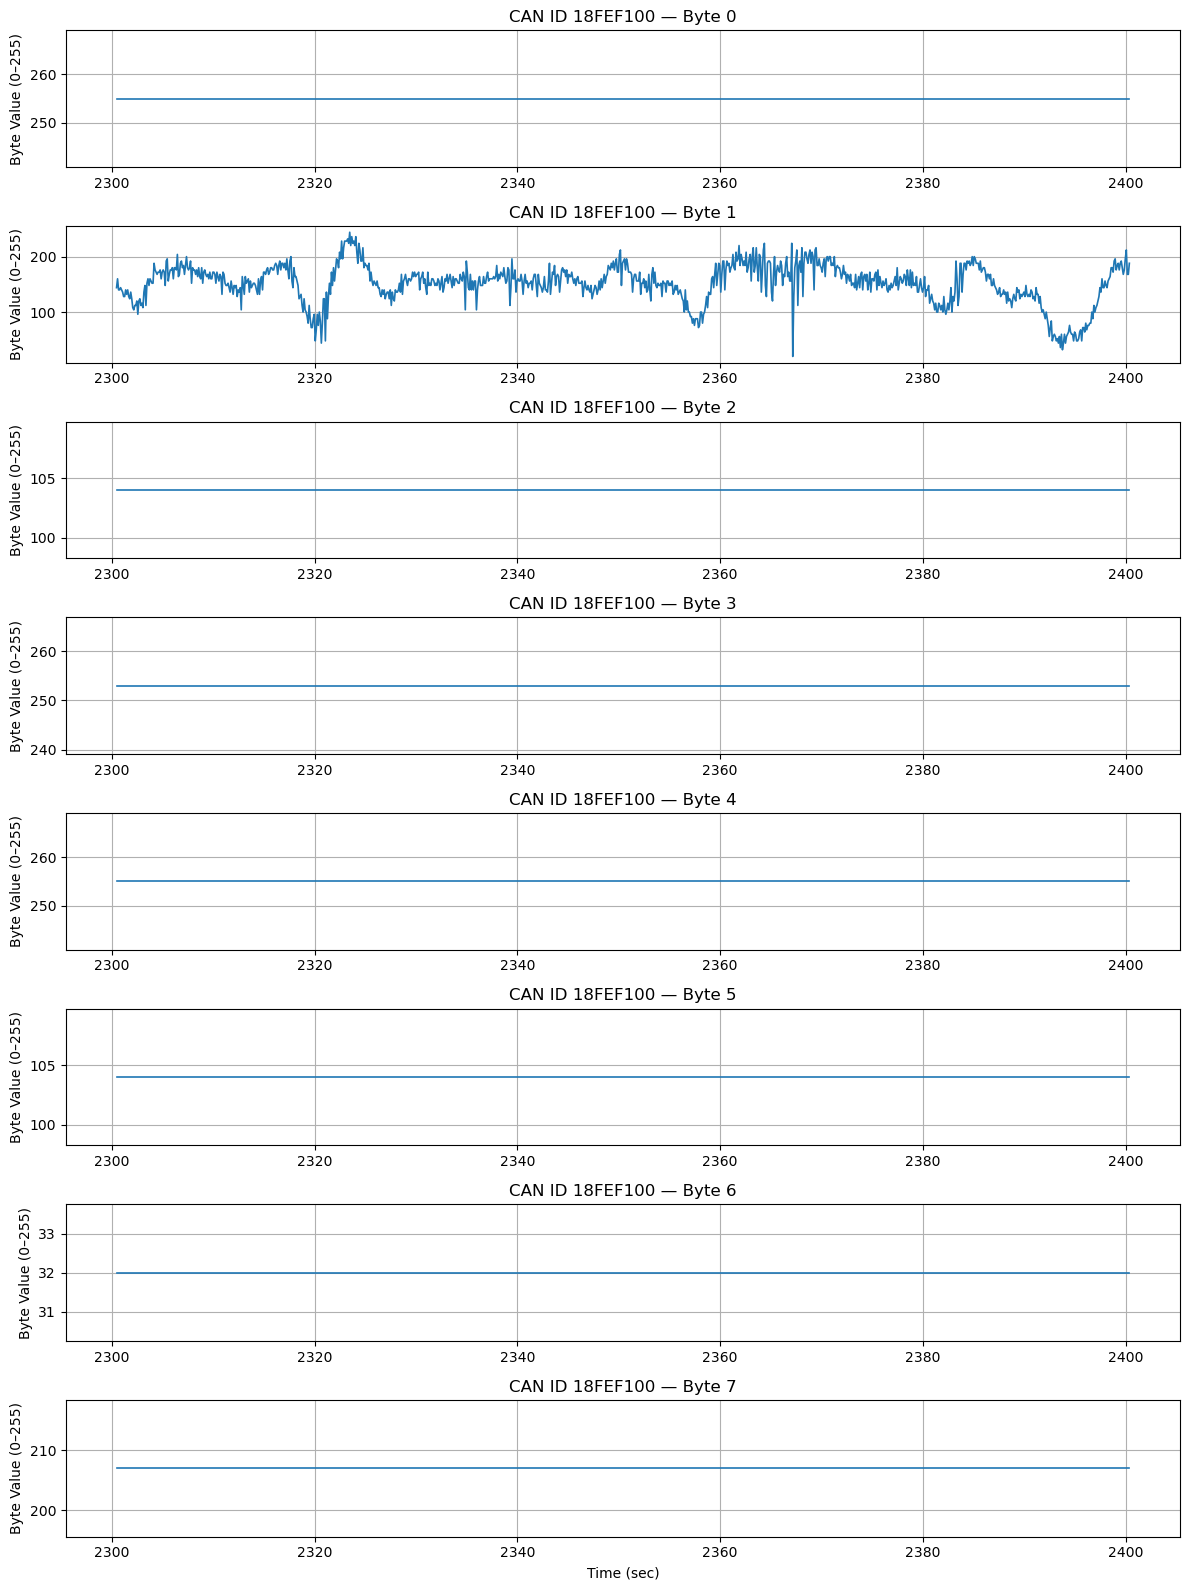

In [13]:
target_id = "18FEF100" # 0386, 0113, 0220, 
#decode_msg_name = "Accel_Report" # WHL_SPD11, TCU13, ESP12, 

timestamps = np.array(can_data_dict[target_id]["timestamps"])
timestamps = timestamps - timestamps[0]   # Normalize time
raw_data = can_data_dict[target_id]["data"]

# Ensure consistent formatting (remove spaces etc.)
raw_data = [msg.replace(" ", "") for msg in raw_data]

num_bytes = len(raw_data[0]) // 2  # Each byte = 2 hex chars

plt.figure(figsize=(12, num_bytes * 2))

for i in range(num_bytes):
    byte_vals = [int(msg[i*2:(i+1)*2], 16) for msg in raw_data]

    plt.subplot(num_bytes, 1, i+1)
    plt.plot(timestamps[23000:24000], byte_vals[23000:24000], linewidth=1.2)
    plt.title(f"CAN ID {target_id} — Byte {i}")
    plt.ylabel("Byte Value (0–255)")
    plt.grid(True)

plt.xlabel("Time (sec)")
plt.tight_layout()
plt.show()

In [7]:
from collections import defaultdict

def mask_can_ids_29bit(can_data_dict):
    masked = defaultdict(lambda: {"timestamps": [], "data": [], "count": 0})

    for can_id_hex, content in can_data_dict.items():
        # parse hex key (handles keys like "0CF00A00")
        fid = int(can_id_hex, 16)

        # mask to 29-bit (removes EFF flag if it was embedded)
        fid_masked = fid & 0x1FFFFFFF

        # back to hex string (uppercase, no 0x), keep width = 8 for J1939 style
        new_key = format(fid_masked, "08X")

        masked[new_key]["timestamps"].extend(content["timestamps"])
        masked[new_key]["data"].extend(content["data"])
        masked[new_key]["count"] += content["count"]

    # Optional: sort each ID's data by timestamp (recommended)
    for k, v in masked.items():
        if len(v["timestamps"]) > 1:
            order = sorted(range(len(v["timestamps"])), key=lambda i: v["timestamps"][i])
            v["timestamps"] = [v["timestamps"][i] for i in order]
            v["data"]       = [v["data"][i]       for i in order]

    return masked
can_data_dict = mask_can_ids_29bit(can_data_dict)

In [8]:
import numpy as np

def make_plottable(v):
    if v is None:
        return np.nan
    if hasattr(v, "value"):         # NamedSignalValue
        return float(v.value)       # convert enum to its numeric code
    return float(v)

In [9]:
import numpy as np
import cantools
from collections import defaultdict

msg_list = [
    "CCVS", "EEC3", "AT1IG1", "AT1OG1", "EGF1", "EEC2", "EngFelThrottleValveInformation", "TC"
]

# You MUST fill this mapping once (message -> CAN ID in your log)
# (these are examples; replace with your real log IDs)
target_id_map = {
    "CCVS": "18FEF100",
    "EEC3": "18FEDF00",
    "AT1IG1": "18F00E00",
    "AT1OG1": "18F00F00",
    "EGF1": "0CF00A00",
    "EEC2": "0CF00331",
    "EngFelThrottleValveInformation": "18FCF200",
    "TC": "18FEDD00",
}

# Load the DBC
if ENV == "jupyter_local" or ENV == "anaconda_prompt":
    dbc_path = r"C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\training data\j1939.dbc"
elif ENV == "osc":
    dbc_path = r'/fs/scratch/PAS3209/kazishb/training_data/data/j1939.dbc'
#dbc_path = r"C:\Users\qazim\OneDrive - The Ohio State University\Application for Fellowship\.Project\SDCS\Generative AI\!Next Research\stealthy_attack_model\training data\hyundai_kia_generic.dbc"

# Load DBC once
db = cantools.database.load_file(dbc_path)

decoded_signals = {}          # global store: signal -> np.array
timestamps_by_msg = {}        # msg -> timestamps array
signals_by_msg = {}           # msg -> list of signal names (as stored in decoded_signals)

for decode_msg_name in msg_list:
    target_id = target_id_map[decode_msg_name]   # <-- you control this (same as your working single-message version)

    # get timestamps/payloads for THIS message's ID
    ts = np.asarray(can_data_dict[target_id]["timestamps"], dtype=float)
    ts = ts - ts[0]
    raw_payloads = can_data_dict[target_id]["data"]
    timestamps_by_msg[decode_msg_name] = ts

    # decode using DBC definition
    msg = db.get_message_by_name(decode_msg_name)
    local = {signal.name: [] for signal in msg.signals}

    for payload in raw_payloads:
        try:
            data_bytes = bytes.fromhex(payload)
            decoded = msg.decode(data_bytes)
            for s in local:
                local[s].append(make_plottable(decoded.get(s, None)))
        except Exception:
            for s in local:
                local[s].append(np.nan)

    # push into global decoded_signals (avoid overwriting collisions)
    stored_names = []
    for s, vals in local.items():
        arr = np.asarray(vals, dtype=float)

        if s not in decoded_signals:
            decoded_signals[s] = arr
            stored_names.append(s)
        else:
            new_name = f"{s}__{decode_msg_name}"
            decoded_signals[new_name] = arr
            stored_names.append(new_name)

    signals_by_msg[decode_msg_name] = stored_names
    print(f"✅ Decoded {decode_msg_name} from {target_id}: stored {len(stored_names)} signals")

✅ Decoded CCVS from 18FEF100: stored 20 signals
✅ Decoded EEC3 from 18FEDF00: stored 9 signals
✅ Decoded AT1IG1 from 18F00E00: stored 10 signals
✅ Decoded AT1OG1 from 18F00F00: stored 10 signals
✅ Decoded EGF1 from 0CF00A00: stored 3 signals
✅ Decoded EEC2 from 0CF00331: stored 14 signals
✅ Decoded EngFelThrottleValveInformation from 18FCF200: stored 14 signals
✅ Decoded TC from 18FEDD00: stored 3 signals


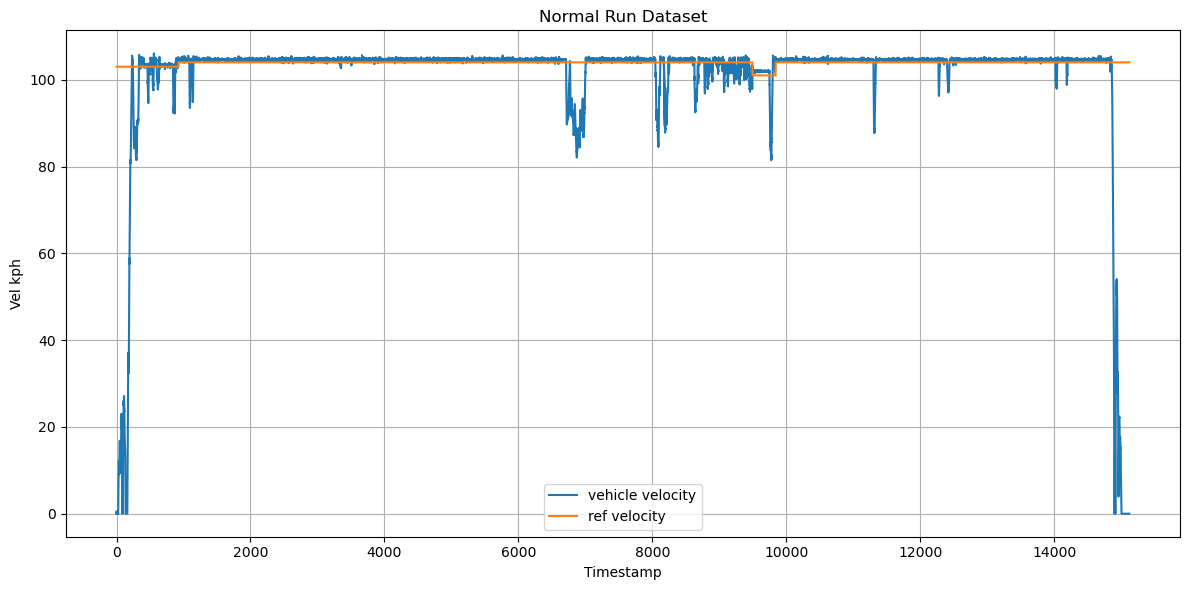

In [10]:
plt.figure(num=5, figsize=(12, 6))
plt.plot(timestamps_by_msg['CCVS'], decoded_signals["WheelBasedVehicleSpeed"], label="vehicle velocity")
plt.plot(timestamps_by_msg['CCVS'], decoded_signals["CruiseCtrlSetSpeed"], label="ref velocity")

#plt.title(f"Decoded signals from CAN ID {target_id} using DBC layout '{decode_msg_name}'")
#plt.title(f"Attack Free Dataset")
plt.title(f"Normal Run Dataset")
plt.xlabel("Timestamp")
plt.ylabel("Vel kph")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [11]:
def interp_to(t_src, x_src, t_dst):
    t_src = np.asarray(t_src, dtype=float)
    x_src = np.asarray(x_src, dtype=float)
    t_dst = np.asarray(t_dst, dtype=float)

    # drop NaNs so interp doesn't blow up
    ok = np.isfinite(t_src) & np.isfinite(x_src)
    t_src, x_src = t_src[ok], x_src[ok]

    if len(t_src) < 2:
        return np.full_like(t_dst, np.nan, dtype=float)

    # np.interp does constant extrapolation outside range.
    # We'll force NaN outside to avoid fake values.
    y = np.interp(t_dst, t_src, x_src)
    y[(t_dst < t_src[0]) | (t_dst > t_src[-1])] = np.nan
    return y

In [12]:
import pandas as pd
import numpy as np

t_vel = np.asarray(timestamps_by_msg["CCVS"], dtype=float)
mask = (t_vel >= 500) & (t_vel <= 14500)

t_vel_win = t_vel[mask]
vel_win   = np.asarray(decoded_signals["WheelBasedVehicleSpeed"], dtype=float)[mask]
ref_win   = np.asarray(decoded_signals["CruiseCtrlSetSpeed"],     dtype=float)[mask]

# master timeline = filtered velocity timeline
t = t_vel_win

data_orig = pd.DataFrame({
    "timestamp": t,
    "vel": vel_win,
    "ref_vel": ref_win,

    # interpolate other signals onto t
    "engine_speed": interp_to(timestamps_by_msg["EEC3"],  decoded_signals["EngsDesiredOperatingSpeed"], t),
    "intake_nox_ppm": interp_to(timestamps_by_msg["AT1IG1"], decoded_signals["Aftertreatment1IntakeNOx"], t),

    "air_mass_flow": interp_to(timestamps_by_msg["EGF1"], decoded_signals["EngIntakeAirMassFlowRate"], t),
    "exhst_mass_flow": interp_to(timestamps_by_msg["EGF1"], decoded_signals["EngExhstGsRcrclton1MassFlowRate"], t),

    "turbo_speed_rpm": interp_to(timestamps_by_msg["TC"], decoded_signals["EngTurbo1Speed"], t),
})


In [13]:
#sampling data down
#data_orig = data_orig.iloc[::downsample_factor].reset_index(drop=True)  # keep every 100th row
data_orig = data_orig.iloc[::downsample_factor].reset_index(drop=True)  #
print(f"data_orig shape: {data_orig.shape}")

data_orig shape: (139941, 8)


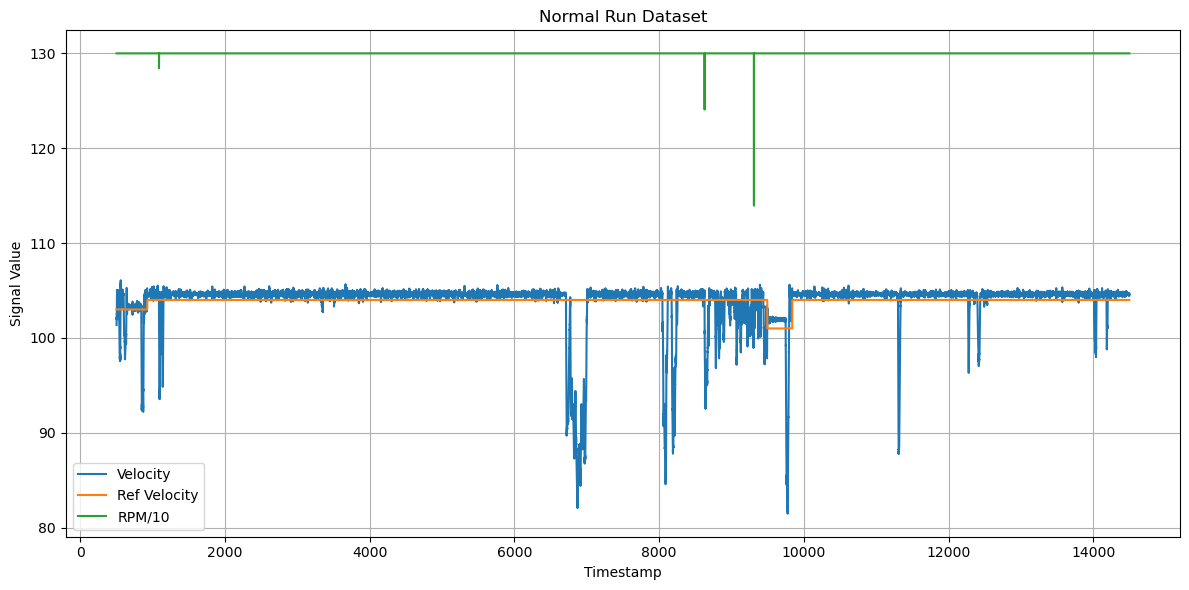

In [14]:
plt.figure(num=5, figsize=(12, 6))
plt.plot(data_orig["timestamp"], data_orig["vel"], label="Velocity")
plt.plot(data_orig["timestamp"], data_orig["ref_vel"], label="Ref Velocity")
plt.plot(data_orig["timestamp"], np.array(data_orig["engine_speed"])/10, label="RPM/10")

#plt.title(f"Decoded signals from CAN ID {target_id} using DBC layout '{decode_msg_name}'")
#plt.title(f"Attack Free Dataset")
plt.title(f"Normal Run Dataset")
plt.xlabel("Timestamp")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(num=6, figsize=(12, 6))
plt.plot(data_orig["timestamp"][40000:45000], data_orig["vel"][40000:45000], label="Vel kph")

#plt.title(f"Decoded signals from CAN ID {target_id} using DBC layout '{decode_msg_name}'")
#plt.title(f"Attack Free Dataset")
plt.title(f"Normal Run Dataset")
plt.xlabel("Timestamp")
plt.ylabel("Signal Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [ ]:
#----------------- Preprocess data for  AE -----------------------#

In [15]:
from sklearn.preprocessing import StandardScaler
import joblib

#features = ['gear', 'eng_speed', 'v_ref', 'vel', 'clutch', 'air_inlet', 'n_turbo1']
#features = ['eng_speed', 'v_ref', 'vel', 'air_inlet', 'n_turbo1']
features = ['vel'] #only keeping the continous signals for AE
#features = ['vel'] #only keeping the continous signals for AE

# 1️⃣ Split first (temporal)
n_total = len(data_orig)
train_end = int(0.7 * n_total)
val_end   = int(0.85 * n_total)

df_train = data_orig.iloc[:train_end]
df_val   = data_orig.iloc[train_end:val_end]
df_test  = data_orig.iloc[val_end:]

# 2️⃣ Fit only on training data
scaler = StandardScaler()
scaler.fit(df_train[features])

# 3️⃣ Transform all sets using the same scaler
df_train_scaled = pd.DataFrame(scaler.transform(df_train[features]),
                               index=df_train.index, columns=features)
df_val_scaled = pd.DataFrame(scaler.transform(df_val[features]),
                             index=df_val.index, columns=features)
df_test_scaled = pd.DataFrame(scaler.transform(df_test[features]),
                              index=df_test.index, columns=features)

# 4️⃣ Save scaler for later inverse_transform
joblib.dump(scaler, "scaler_AE.pkl")

# 5️⃣ Quick check
print("Means after scaling (train set):")
print(df_train_scaled.mean().round(4))
print("\nStds after scaling (train set):")
print(df_train_scaled.std().round(4))

Means after scaling (train set):
vel   -0.0
dtype: float64

Stds after scaling (train set):
vel    1.0
dtype: float64


In [16]:
print("Train means:", df_train_scaled.mean().round(4).to_dict())
print("Train stds :", df_train_scaled.std().round(4).to_dict())

# confirm per-feature stats inside scaler
print("Saved mean_:", dict(zip(features, scaler.mean_)))
print("Saved scale_:", dict(zip(features, scaler.scale_)))

Train means: {'vel': -0.0}
Train stds : {'vel': 1.0}
Saved mean_: {'vel': np.float64(103.60171722192165)}
Saved scale_: {'vel': np.float64(3.1725658208519913)}


In [17]:
#---------fixed-length windows for LSTM/GRU training-------------#

def create_sequences(data, seq_len=50):
    X = []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
    return np.array(X)

seq_len = 50
X_train = create_sequences(df_train_scaled.values.astype(np.float32), seq_len)
X_val   = create_sequences(df_val_scaled.values.astype(np.float32), seq_len)
X_test  = create_sequences(df_test_scaled.values.astype(np.float32), seq_len)

print(f"Shape train: {X_train.shape}, val: {X_val.shape}, test: {X_test.shape}")

Shape train: (97908, 50, 1), val: (20941, 50, 1), test: (20942, 50, 1)


In [16]:
#-------------- AutoEncoder IMPLEMENTATION ----------------------# 

In [20]:
import os
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset

# -------------------- DataLoaders -------------------- #
device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32)),
    batch_size=64, shuffle=True, pin_memory=(device == "cuda")
)
val_loader = DataLoader(
    TensorDataset(torch.tensor(X_val, dtype=torch.float32)),
    batch_size=64, shuffle=False, pin_memory=(device == "cuda")
)

# -------------------- Model -------------------- #
criterion = nn.MSELoss()

In [23]:
#---------------Load Trained AE model---------------------
# ------------------------------
# Conditional load logic
# ------------------------------
from pathlib import Path
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
save_dir = Path("models_checkpoint")
best_path = save_dir / "AE_best.pth"
latest_ckpt = save_dir / "AE_latest.pt"
if best_path.exists():
    print("✔ Loading AE_best.pth")
    ae.load_state_dict(torch.load(best_path, map_location=device))
else:
    print("⚠ AE_best.pth not found — loading AE_latest.pt")
    ckpt = torch.load(latest_ckpt, map_location=device)
    ae.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded checkpoint from epoch {ckpt.get('epoch', 'NA')}")

ae.eval()
#to freeze AE gradients during GAN training
for p in ae.parameters():
    p.requires_grad_(False)
    
ae.train()  # cuDNN LSTM backward allowed, weights still frozen

✔ Loading AE_best.pth


C:\Users\qazim\AppData\Local\Temp\ipykernel_41772\373519014.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ae.load_state_dict(torch.load(best_path, map_location=device

LSTMAutoencoder(
  (encoder): LSTM(1, 128, batch_first=True)
  (fc_enc): Linear(in_features=128, out_features=1, bias=True)
  (fc_dec): Linear(in_features=1, out_features=128, bias=True)
  (decoder): LSTM(128, 128, batch_first=True)
  (out): Linear(in_features=128, out_features=1, bias=True)
)

In [24]:
ae = ae.to(device)
ae.eval()
for p in ae.parameters():
    p.requires_grad_(False)
#ae.train()  # allow RNN backward

In [25]:
import torch
from scipy.stats import chi2
import joblib
import numpy as np


scaler = joblib.load("scaler_AE.pkl")

# --------------------------
# 3) Batched inference on X_test (scaled domain)
# --------------------------
# Make sure X_test is float32 on CPU
X_test_f32 = X_test.astype(np.float32)

test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_f32)),
    batch_size=256,          # if still OOM, reduce to 128 or 64
    shuffle=False,
    pin_memory=(device == "cuda")
)

recon_scaled_list = []
x_scaled_list = []

with torch.no_grad():
    for (x_batch,) in test_loader:
        x_batch = x_batch.to(device, non_blocking=True)

        recon_batch, _ = ae(x_batch)

        # Move outputs to CPU immediately
        recon_scaled_list.append(recon_batch.cpu().numpy())
        x_scaled_list.append(x_batch.cpu().numpy())

# Concatenate back to full arrays on CPU
X_test_scaled_np = np.concatenate(x_scaled_list, axis=0)      # (N, T, F)
recon_scaled_np  = np.concatenate(recon_scaled_list, axis=0)  # (N, T, F)

# Optional: free cached GPU memory
del test_loader
torch.cuda.empty_cache()

# --------------------------
# 4) Inverse transform back to physical units
# --------------------------
num_samples, seq_len, num_features = X_test_scaled_np.shape

X_test_flat = X_test_scaled_np.reshape(-1, num_features)   # (N*T, F)
recon_flat  = recon_scaled_np.reshape(-1, num_features)

X_test_inv = scaler.inverse_transform(X_test_flat).reshape(num_samples, seq_len, num_features)
recon_inv  = scaler.inverse_transform(recon_flat).reshape(num_samples, seq_len, num_features)


Test windows: 20942, seq_len: 50, features: 1


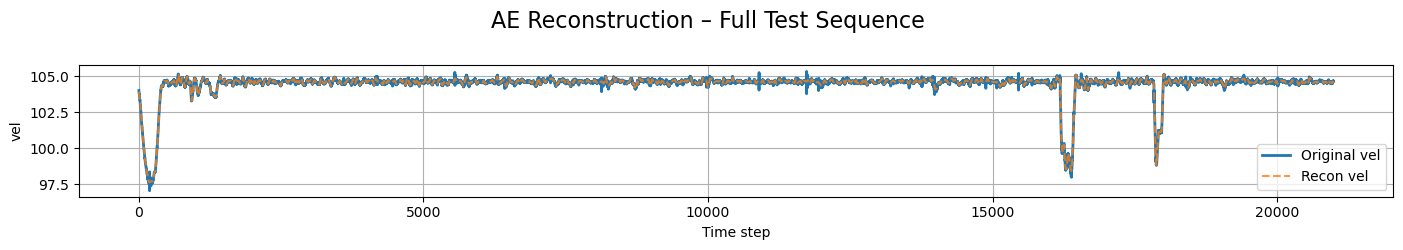

<Figure size 640x480 with 0 Axes>

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Shape of test data
num_samples, seq_len, num_features = X_test_inv.shape
print(f"Test windows: {num_samples}, seq_len: {seq_len}, features: {num_features}")

# --- 1️⃣ Reconstruct continuous signal by averaging overlaps ---
# Allocate arrays for accumulation
total_len = num_samples + seq_len - 1
recon_full = np.zeros((total_len, num_features))
count = np.zeros(total_len)

for i in range(num_samples):
    recon_full[i:i+seq_len] += recon_inv[i, :, :]
    count[i:i+seq_len] += 1

# Avoid division by zero
count[count == 0] = 1
recon_full /= count[:, None]

# Same process for ground truth (if you want to compare)
orig_full = np.zeros((total_len, num_features))
count2 = np.zeros(total_len)
for i in range(num_samples):
    orig_full[i:i+seq_len] += X_test_inv[i, :, :]
    count2[i:i+seq_len] += 1
count2[count2 == 0] = 1
orig_full /= count2[:, None]

# --- 2️⃣ Plot all features over full time range ---
time_axis = np.arange(total_len)

plt.figure(figsize=(14, 2.5 * num_features))
for f in range(num_features):
    plt.subplot(num_features, 1, f + 1)
    plt.plot(time_axis, orig_full[:, f], label=f'Original {features[f]}', linewidth=2)
    plt.plot(time_axis, recon_full[:, f], '--', label=f'Recon {features[f]}', alpha=0.8)
    plt.ylabel(features[f])
    plt.grid(True)
    plt.legend(fontsize=10)
plt.suptitle("AE Reconstruction – Full Test Sequence", fontsize=16)
plt.xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
plt.savefig(f"figures/2validation_{experiment_tag}.png", dpi=300, bbox_inches='tight')

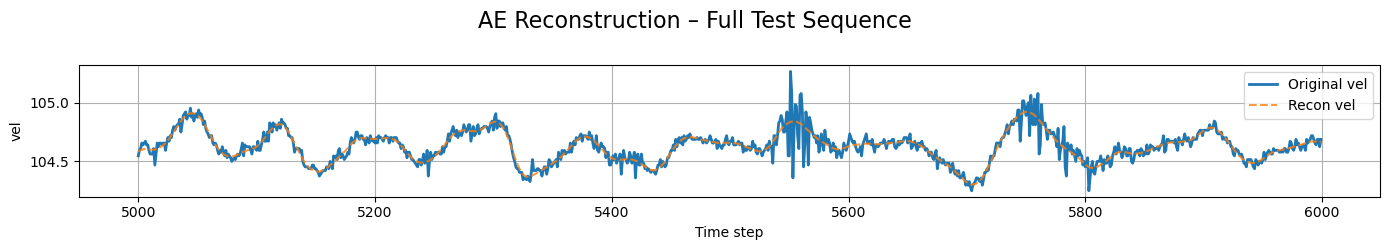

<Figure size 640x480 with 0 Axes>

In [25]:
plt.figure(figsize=(14, 2.5 * num_features))
for f in range(num_features):
    plt.subplot(num_features, 1, f + 1)
    plt.plot(time_axis[5000:6000], orig_full[:, f][5000:6000], label=f'Original {features[f]}', linewidth=2)
    plt.plot(time_axis[5000:6000], recon_full[:, f][5000:6000], '--', label=f'Recon {features[f]}', alpha=0.8)
    plt.ylabel(features[f])
    plt.grid(True)
    plt.legend(fontsize=10)
plt.suptitle("AE Reconstruction – Full Test Sequence", fontsize=16)
plt.xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
plt.savefig(f"figures/2validation_{experiment_tag}.png", dpi=300, bbox_inches='tight')

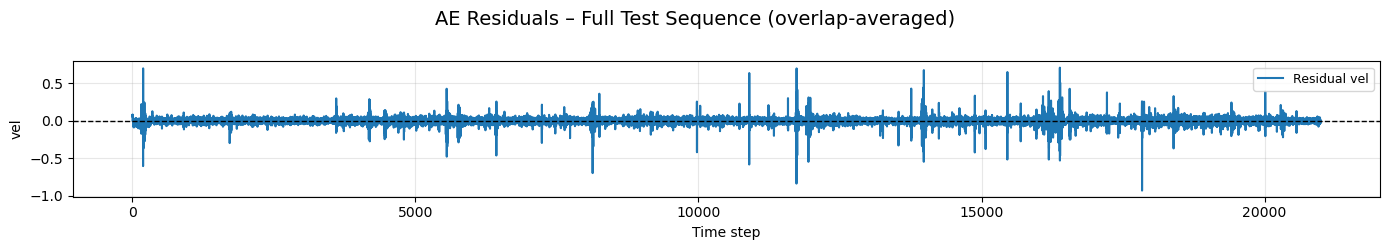

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# residuals in window form
residuals_win = X_test_inv - recon_inv   # (N, L, F)
N, L, F = residuals_win.shape

total_len = N + L - 1
res_full = np.zeros((total_len, F), dtype=np.float64)
count = np.zeros(total_len, dtype=np.float64)

for i in range(N):
    res_full[i:i+L] += residuals_win[i]
    count[i:i+L] += 1

count[count == 0] = 1
res_full /= count[:, None]

time_axis = np.arange(total_len)

plt.figure(figsize=(14, 2.5 * F))
for f in range(F):
    ax = plt.subplot(F, 1, f + 1)
    ax.plot(time_axis, res_full[:, f], linewidth=1.5, label=f"Residual {features[f]}")
    ax.axhline(0, color="k", linestyle="--", linewidth=1)
    ax.set_ylabel(features[f])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc="upper right")

plt.suptitle("AE Residuals – Full Test Sequence (overlap-averaged)", fontsize=14)
plt.xlabel("Time step")
plt.tight_layout(rect=[0, 0, 1, 0.97])

# IMPORTANT: save before show in scripts
Path("figures").mkdir(exist_ok=True)
plt.savefig(f"figures/residuals_full_{experiment_tag}.png", dpi=300, bbox_inches="tight")
plt.show()
#plt.close()

In [28]:
# residuals_win: (N, L, F=1) in physical units
r = residuals_win[:, -1, 0]          # (N,) last-step residual per window | A 1D array of scalar residuals, one per window, taken at the most recent time step

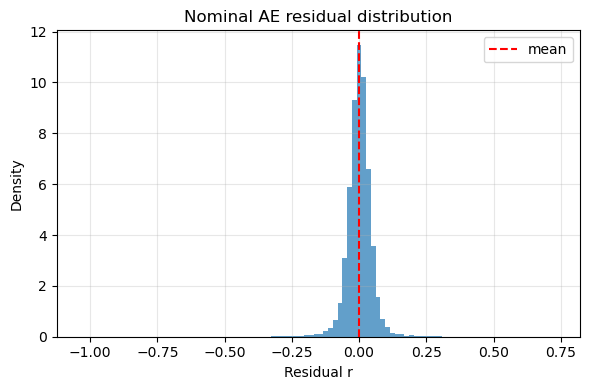

In [28]:
plt.figure(figsize=(6,4))
plt.hist(r, bins=100, density=True, alpha=0.7)
plt.axvline(np.mean(r), color="r", linestyle="--", label="mean")
plt.title("Nominal AE residual distribution")
plt.xlabel("Residual r")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

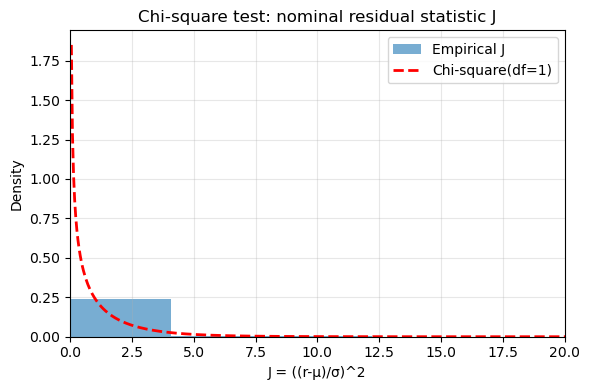

mean = 0.0004100805
sigma = 0.05127227


In [29]:
mu = np.mean(r)
sigma = np.std(r, ddof=1)

J = ((r - mu) / (sigma + 1e-12))**2

from scipy.stats import chi2

plt.figure(figsize=(6,4))
plt.hist(J, bins=100, density=True, alpha=0.6, label="Empirical J")

x = np.linspace(0, np.percentile(J, 99.5), 500)
#x = np.linspace(0, 20, 500)
plt.plot(x, chi2.pdf(x, df=1), 'r--', lw=2, label="Chi-square(df=1)")

plt.xlim(0, 20)   # 
plt.ylim(bottom=0)

plt.title("Chi-square test: nominal residual statistic J")
plt.xlabel("J = ((r-μ)/σ)^2")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("mean =", mu)
print("sigma =", sigma)

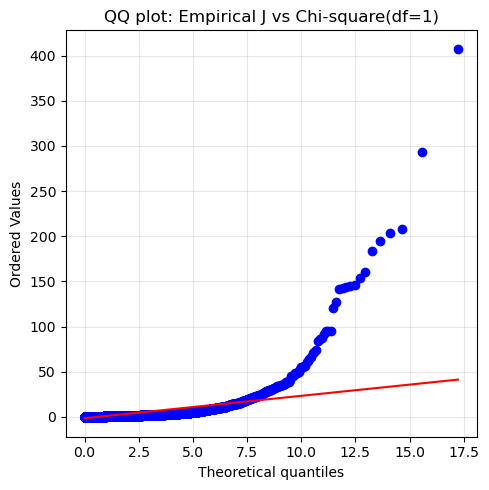

In [30]:
from scipy.stats import probplot

plt.figure(figsize=(5,5))
probplot(J, dist=chi2, sparams=(1,), plot=plt)
plt.title("QQ plot: Empirical J vs Chi-square(df=1)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
alpha = 0.01
gamma = chi2.ppf(1-alpha, df=1)

empirical_fa = np.mean(J > gamma)

print(f"Target FA rate: {alpha}")
print(f"Empirical FA rate (chi-square): {empirical_fa:.4f}")

NameError: name 'J' is not defined

In [30]:
#-----------Chi-square τ extracted from the data using AE-----------------
from scipy.stats import chi2
import numpy as np

sigma = np.std(r, ddof=1)            # residual std estimate (clean)
alpha = 0.01                         # false alarm probability
gamma = chi2.ppf(1 - alpha, df=1)    # chi-square threshold

tau_chi = np.sqrt(gamma) * sigma         # threshold on |r|, the max allowed value of r to stay within stealth threshold

print("sigma =", sigma)
print("gamma =", gamma)
print("tau chi based  =", tau_chi)

J = (r / sigma)**2   # should be ~chi2_1 under clean data

# You can check empirical false alarm rate:
fa_rate_emp = np.mean(J > gamma)
print("Empirical FA rate:", fa_rate_emp)

sigma = 0.05127227
gamma = 6.6348966010212145
tau chi based  = 0.13206861382122365
Empirical FA rate: 0.019959889217839748


In [31]:
#------- computed tau for scaled values as its going to be used in GAN training
residuals_win_scaled = X_test_scaled_np - recon_scaled_np
r_scaled = residuals_win_scaled[:, -1, 0]
sigma = np.std(r_scaled, ddof=1)            # residual std estimate (clean)
alpha = 0.01                         # false alarm probability
gamma = chi2.ppf(1 - alpha, df=1)    # chi-square threshold

tau_chi_scaled = np.sqrt(gamma) * sigma         # threshold on |r|, the max allowed value of r to stay within stealth threshold

print("sigma =", sigma)
print("gamma =", gamma)
print("tau chi based  =", tau_chi_scaled)

J = (r_scaled / sigma)**2   # should be ~chi2_1 under clean data

# You can check empirical false alarm rate:
fa_rate_emp = np.mean(J > gamma)
print("Empirical FA rate:", fa_rate_emp)

sigma = 0.016161134
gamma = 6.6348966010212145
tau chi based  = 0.04162832373747925
Empirical FA rate: 0.019959889217839748


tau_percentile: 0.18062422
Empirical FA rate: 0.01002769554006303


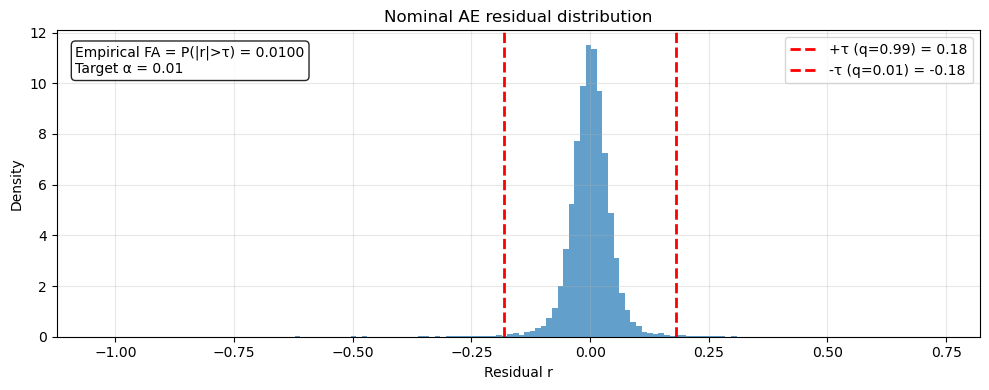

In [32]:
#---------- percentile-based 𝜏 ----------#
fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)
"""
τq	​=Quantile q	​(∣rk∣)
For 𝑞 = 0.99
P(∣rk∣>τ0.99)≈1%
"""
q = 0.99
tau_perc = np.quantile(np.abs(r), q, axis=0)   # (F,)
#tau_global   = float(np.quantile(np.abs(r).reshape(-1), q))  # scalar
fa_emp = np.mean(np.abs(r) > tau_perc)

print("tau_percentile:", tau_perc)
print("Empirical FA rate:", fa_emp)
#print("tau_global  :", tau_global)

plt.figure(figsize=(10,4))
plt.hist(r, bins=150, density=True, alpha=0.7)

# two-sided thresholds
plt.axvline(+tau_perc, color="r", linestyle="--", linewidth=2, label=f"+τ (q={q:.2f}) = {tau_perc:.2f}")
plt.axvline(-tau_perc, color="r", linestyle="--", linewidth=2, label=f"-τ (q=0.01) = {(-tau_perc):.2f}")

plt.title("Nominal AE residual distribution")
plt.xlabel("Residual r")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
# annotate empirical FA on the figure
plt.text(
    0.02, 0.95,
    f"Empirical FA = P(|r|>τ) = {fa_emp:.4f}\nTarget α = {alpha:.2f}",
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
)

plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(fig_dir / "nominal_residual_distr_tau_perc.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
#------- computed tau for scaled values as its going to be used in GAN training
residuals_win_scaled = X_test_scaled_np - recon_scaled_np
r_scaled = residuals_win_scaled[:, -1, 0]
tau_perc_scaled = float(np.quantile(np.abs(r_scaled), 0.99))  # or chi-square version in scaled space
print("tau:", tau_perc_scaled)

tau: 0.05693318694829941


In [34]:
#-------------- cWGAN IMPLEMENTATION ----------------------#

In [35]:
from sklearn.preprocessing import StandardScaler
import joblib
import pandas as pd
import numpy as np

"""
data_orig = pd.DataFrame({
    "timestamp": t,
    "vel": vel_win,
    "ref_vel": ref_win,

    # interpolate other signals onto t
    "engine_speed": interp_to(timestamps_by_msg["EEC3"],  decoded_signals["EngsDesiredOperatingSpeed"], t),
    "intake_nox_ppm": interp_to(timestamps_by_msg["AT1IG1"], decoded_signals["Aftertreatment1IntakeNOx"], t),

    "air_mass_flow": interp_to(timestamps_by_msg["EGF1"], decoded_signals["EngIntakeAirMassFlowRate"], t),
    "exhst_mass_flow": interp_to(timestamps_by_msg["EGF1"], decoded_signals["EngExhstGsRcrclton1MassFlowRate"], t),

    "turbo_speed_rpm": interp_to(timestamps_by_msg["TC"], decoded_signals["EngTurbo1Speed"], t),
})
"""
#cond_features = ['slope','eng_speed','v_ref','accel1','air_inlet','n_turbo1']
#"timestamp": np.asarray(timestamps, dtype=float),     "throttle":  np.asarray(decoded_signals["TQI"], dtype=float),"vel":  np.asarray(decoded_signals["VS"],  dtype=float), "rpm": np.asarray(decoded_signals["N"],   dtype=float),
cond_features = ['ref_vel','engine_speed', 'intake_nox_ppm', 'air_mass_flow', 'exhst_mass_flow', 'turbo_speed_rpm']
target_feature = 'vel'

# 1️⃣ Split first (temporal)
n_total = len(data_orig)
train_end = int(0.7 * n_total)
val_end   = int(0.85 * n_total)

df_train = data_orig.iloc[:train_end]
df_val   = data_orig.iloc[train_end:val_end]
df_test  = data_orig.iloc[val_end:]

#n_total = len(data_orig)
#train_end = int(0.7 * n_total)
#val_end   = int(0.85 * n_total)

#df_train = data_orig.iloc[:train_end].reset_index(drop=True)
#df_val   = data_orig.iloc[train_end:val_end].reset_index(drop=True)
#df_test  = data_orig.iloc[val_end:].reset_index(drop=True)

# fit only on train
scaler_x = StandardScaler().fit(df_train[cond_features])

#scaler_y = StandardScaler().fit(df_train[[target_feature]])
# use AE scaler for y to guarantee same normalization
scaler_y = joblib.load("scaler_AE.pkl")

# transform
X_train = scaler_x.transform(df_train[cond_features]).astype(np.float32)  
X_val   = scaler_x.transform(df_val[cond_features]).astype(np.float32)  
X_test  = scaler_x.transform(df_test[cond_features]).astype(np.float32)  

y_train = scaler_y.transform(df_train[[target_feature]]).astype("float32").squeeze(-1)  # (N,)
y_val   = scaler_y.transform(df_val[[target_feature]]).astype("float32").squeeze(-1)
y_test  = scaler_y.transform(df_test[[target_feature]]).astype("float32").squeeze(-1)

joblib.dump(scaler_x, "scaler_cwgan_X.pkl")
joblib.dump(scaler_y, "scaler_cwgan_y.pkl")

['scaler_cwgan_y.pkl']

In [36]:
import numpy as np

def create_conditional_windows(X, y, seq_len=50, stride=5):
    X_hist, y_hist, y_next = [], [], []
    N = len(y)
    for t in range(seq_len, N, stride):
        X_hist.append(X[t-seq_len:t,:])
        y_hist.append(y[t-seq_len:t].reshape(seq_len, 1))       
        y_next.append([y[t]])          # (T,)
        
    return (np.asarray(X_hist, dtype=np.float32),
            np.asarray(y_hist, dtype=np.float32),
            np.asarray(y_next, dtype=np.float32))

seq_len = 50
stride = 5   # recommend overlap
X_train_seq, y_hist_train_seq, y_train_seq = create_conditional_windows(X_train, y_train, seq_len, stride)
X_val_seq,   y_hist_val_seq, y_val_seq   = create_conditional_windows(X_val,   y_val,   seq_len, stride)

print("Train:", X_train_seq.shape, y_hist_train_seq.shape, y_train_seq.shape)
print("Val  :", X_val_seq.shape,   y_hist_val_seq.shape,   y_val_seq.shape)

Train: (19582, 50, 6) (19582, 50, 1) (19582, 1)
Val  : (4189, 50, 6) (4189, 50, 1) (4189, 1)


In [37]:
import torch
from torch.utils.data import TensorDataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

# Convert numpy -> torch once (CPU tensors)
X_train_t     = torch.tensor(X_train_seq, dtype=torch.float32)          # (N,L,C)
y_hist_train_t= torch.tensor(y_hist_train_seq, dtype=torch.float32)     # (N,L,1)
y_train_t     = torch.tensor(y_train_seq, dtype=torch.float32)          # (N,1)

X_val_t       = torch.tensor(X_val_seq, dtype=torch.float32)
y_hist_val_t  = torch.tensor(y_hist_val_seq, dtype=torch.float32)
y_val_t       = torch.tensor(y_val_seq, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_hist_train_t, y_train_t),
    batch_size=64,
    shuffle=True,
    drop_last=True,                 # helpful for WGAN-GP stable batch sizes
    pin_memory=(device == "cuda")
)

val_loader = DataLoader(
    TensorDataset(X_val_t, y_hist_val_t, y_val_t),
    batch_size=64,
    shuffle=False,
    drop_last=False,
    pin_memory=(device == "cuda")
)

In [38]:
# --- Sanity: shapes + alignment ---
Xh, yh, y_real = next(iter(train_loader))

print("Xh:", Xh.shape)      # (B,L,6)
print("yh:", yh.shape)      # (B,L,1)
print("y_real:", y_real.shape)  # (B,1)

# alignment: y_real should equal last element + 1 step (in the original y stream)
# we can at least verify "yh last step is not equal to y_real" generally
print("yh[-1] mean:", yh[:, -1, 0].mean().item())
print("y_real mean:", y_real[:, 0].mean().item())
# expected: (B,L,C) (B,L,1) (B, C) (B,1)

Xh: torch.Size([64, 50, 6])
yh: torch.Size([64, 50, 1])
y_real: torch.Size([64, 1])
yh[-1] mean: -0.016209041699767113
y_real mean: -0.022827066481113434


In [39]:
#Gradient penalty (WGAN-GP)
def gradient_penalty(D, Xh, yh, y_real, y_fake, device):
    # interpolate only over y_next (B,1)
    B = y_real.size(0)
    eps = torch.rand(B, 1, device=device)
    y_hat = eps * y_real + (1 - eps) * y_fake
    y_hat.requires_grad_(True)

    d_hat = D(Xh, yh, y_hat)  # (B,1)

    grads = torch.autograd.grad(
        outputs=d_hat,
        inputs=y_hat,
        grad_outputs=torch.ones_like(d_hat),
        create_graph=True,
        retain_graph=True,
        only_inputs=True
    )[0]  # (B,1)

    gp = ((grads.norm(2, dim=1) - 1) ** 2).mean()
    return gp

In [40]:
import torch
import numpy as np

@torch.no_grad()
def eval_generator_rmse(G, val_loader, device, z_dim, mode="mc", k_samples=4):
    """
    Returns RMSE on y_next in scaled space.
    mode:
      - "z0": use z=0 (deterministic)
      - "mc": Monte Carlo average over k_samples z draws
    """
    G.eval()
    se_sum = 0.0
    n_sum  = 0

    for Xh, yh, y_real in val_loader:
        Xh = Xh.to(device, non_blocking=True)
        yh = yh.to(device, non_blocking=True)
        y_real = y_real.to(device, non_blocking=True)  # (B,1)

        if mode == "z0":
            z = torch.zeros(Xh.size(0), z_dim, device=device)
            y_hat = G(Xh, yh, z)  # (B,1)

        elif mode == "mc":
            preds = []
            for _ in range(k_samples):
                z = torch.randn(Xh.size(0), z_dim, device=device)
                preds.append(G(Xh, yh, z))
            y_hat = torch.mean(torch.stack(preds, dim=0), dim=0)  # (B,1)

        else:
            raise ValueError("mode must be 'z0' or 'mc'")

        se_sum += torch.sum((y_hat - y_real) ** 2).item()
        n_sum  += y_real.numel()

    rmse = float(np.sqrt(se_sum / max(n_sum, 1)))
    return rmse

In [43]:
import torch
"""
Returns:
  val_wgap    : critic gap proxy for Wasserstein-1 (EMD)  (scalar)
  val_stealth : fraction of samples with |resid_last| <= tau (scalar in [0,1])
  val_absr    : mean |resid_last| (scalar)
  val_impact  : mean impact MSE = E[(y_fake - y_real)^2] (scalar)
"""
@torch.no_grad()
def eval_stealth_wgap_impact(
    G, D, ae, loader, device, z_dim, tau, k_samples=4
):

    G.eval(); D.eval(); ae.eval()

    stealth_sum = 0.0
    absr_sum    = 0.0
    wgap_sum    = 0.0
    impact_sum  = 0.0
    n_sum       = 0

    for Xh, yh, y_real in loader:
        Xh = Xh.to(device, non_blocking=True)
        yh = yh.to(device, non_blocking=True)
        y_real = y_real.to(device, non_blocking=True)
        if y_real.ndim == 1:
            y_real = y_real.unsqueeze(1)

        B = Xh.size(0)
        n_sum += B

        # Critic on real
        d_real = D(Xh, yh, y_real).mean().item()

        # Monte Carlo average over z
        d_fake_acc   = 0.0
        stealth_acc  = 0.0
        absr_acc     = 0.0
        impact_acc   = 0.0

        for _ in range(k_samples):
            z = torch.randn(B, z_dim, device=device)
            y_fake = G(Xh, yh, z)

            # Critic on fake
            d_fake_acc += D(Xh, yh, y_fake).mean().item()

            # AE residual last step
            y_fake_step = y_fake.unsqueeze(-1)  # (B,1,1)
            y_win_fake  = torch.cat([yh[:, 1:, :], y_fake_step], dim=1)  # (B,50,1)

            recon, _ = ae(y_win_fake)
            resid_last = (y_win_fake - recon)[:, -1, :]  # (B,1)

            # Stealth metrics
            stealth_acc += (torch.abs(resid_last) <= tau).float().mean().item()
            absr_acc    += torch.abs(resid_last).mean().item()

            # Impact metric (y_real proxy)
            impact_acc  += torch.mean((y_fake - y_real) ** 2).item()

        d_fake_mean = d_fake_acc / k_samples
        wgap_sum   += (d_real - d_fake_mean) * B

        stealth_sum += (stealth_acc / k_samples) * B
        absr_sum    += (absr_acc / k_samples) * B
        impact_sum  += (impact_acc / k_samples) * B

    val_wgap    = wgap_sum / max(n_sum, 1)
    val_stealth = stealth_sum / max(n_sum, 1)
    val_absr    = absr_sum / max(n_sum, 1)
    val_impact  = impact_sum / max(n_sum, 1)
    return val_wgap, val_stealth, val_absr, val_impact


In [44]:
lambda_gp = 5.0
lambda_AE = 500        # tune
lambda_attack = 0.0015    # tune (start small)

tau = tau_perc_scaled
#----- for score
stealth_floor = 0.90     # stealth constraint after warmup
wgap_cap = 1.0           # optional: reject if |wgap| too large after warmup

#boundary-hugging 
lambda_push   = 0.1       # tune (start small e.g., 0.01–0.2)
push_sign     = +1         # +1 => hug +tau,  -1 => hug -tau
beta          = 0.90       # target inside boundary: beta*tau

In [46]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

if DO_TRAIN:
    epochs = range(1, len(G_losses) + 1)

    plt.figure(figsize=(10,4))
    plt.plot(epochs, D_losses, label="Critic loss (D)")
    plt.plot(epochs, G_losses, label="Generator loss (G)")
    plt.title("cWGAN Training Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_dir / f"loss_curves_{experiment_tag}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [47]:
import numpy as np
import matplotlib.pyplot as plt

if DO_TRAIN:
    stealth = np.asarray(val_stealth_hist, dtype=float)
    impact  = np.asarray(val_impact_hist, dtype=float)

    n = min(len(stealth), len(impact))
    stealth = stealth[:n]
    impact  = impact[:n]

    plt.figure(figsize=(7, 5))
    plt.scatter(stealth, impact)
    plt.xlabel("Val Stealth Rate")
    plt.ylabel("Val Impact MSE")
    plt.title("Impact vs Stealth across epochs")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [48]:
import numpy as np
import matplotlib.pyplot as plt

if DO_TRAIN:
    # --- make all series same length (safe even if some are longer) ---
    series = {
        "val_scores": val_scores,
        "val_stealth_hist": val_stealth_hist,
        "val_absr_hist": val_absr_hist,
        "val_impact_hist": val_impact_hist,
        "val_wgap_hist": val_wgap_hist,
    }

    min_len = min(len(v) for v in series.values())
    print({k: len(v) for k, v in series.items()}, "=> using min_len =", min_len)

    val_scores_plot   = np.asarray(val_scores[:min_len], dtype=float)
    val_stealth_plot  = np.asarray(val_stealth_hist[:min_len], dtype=float)
    val_absr_plot     = np.asarray(val_absr_hist[:min_len], dtype=float)
    val_impact_plot   = np.asarray(val_impact_hist[:min_len], dtype=float)
    val_wgap_plot     = np.asarray(val_wgap_hist[:min_len], dtype=float)

    epochs = np.arange(1, min_len + 1)


    # 1) Composite score
    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_scores_plot, marker='o')
    plt.axvline(warmup_epochs, color='gray', linestyle='--', label='Warmup end')
    plt.title("Composite Validation Score")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Stealth
    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_stealth_plot * 100, marker='o')
    plt.axhline(stealth_floor * 100, color='r', linestyle='--', label='Stealth floor')
    plt.axvline(warmup_epochs, color='gray', linestyle='--')
    plt.title("Validation Stealth Rate (%)")
    plt.xlabel("Epoch")
    plt.ylabel("Stealth %")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) |r|
    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_absr_plot, marker='o')
    plt.axhline(tau, color='r', linestyle='--', label='tau')
    plt.title("Mean |Residual| (Validation)")
    plt.xlabel("Epoch")
    plt.ylabel("|r|")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 4) Impact
    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_impact_plot, marker='o')
    plt.axvline(warmup_epochs, color='gray', linestyle='--')
    plt.title("Validation Impact (MSE under stealth)")
    plt.xlabel("Epoch")
    plt.ylabel("Impact MSE")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 5) Wgap
    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_wgap_plot, marker='o')
    plt.axhline(+wgap_cap, color='r', linestyle='--')
    plt.axhline(-wgap_cap, color='r', linestyle='--', label='wgap cap')
    plt.axvline(warmup_epochs, color='gray', linestyle='--')
    plt.title("Validation Critic Gap (Wgap)")
    plt.xlabel("Epoch")
    plt.ylabel("E[D(real)] - E[D(fake)]")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [49]:
# ------------------------------ # Conditional load logic # ------------------------------
from pathlib import Path
import torch

save_dir = Path("models_checkpoint")
wgan_best = save_dir / "WGAN_best.pt"
wgan_final = save_dir / "WGAN_final.pt"

if wgan_final.exists():
    print("✔ Found WGAN_final.pt — loading WGAN_final.pt")
    ckpt = torch.load(wgan_final, map_location=device)

elif wgan_best.exists():
    print("✔ Found WGAN_best.pt — loading best checkpoint")
    ckpt = torch.load(wgan_best, map_location=device)

else:
    raise FileNotFoundError("No WGAN checkpoint found (WGAN_best.pt or WGAN_final.pt).")

# Restore models
G.load_state_dict(ckpt["G_state_dict"])
D.load_state_dict(ckpt["D_state_dict"])

G.eval()
D.eval()

print(f"Loaded epoch: {ckpt.get('epoch','NA')}, best_val_rmse: {ckpt.get('best_val_rmse','NA')}")

✔ Found WGAN_final.pt — loading WGAN_final.pt
Loaded epoch: 19, best_val_rmse: NA


C:\Users\qazim\AppData\Local\Temp\ipykernel_41772\1065296929.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(wgan_final, map_location=device)


In [50]:
"""
✔️ Healthy behavior

Stealth % rises quickly during warmup, then stabilizes ≥ stealth_floor

|r| stays near but below τ (not collapsing to zero)

Impact increases after warmup

Wgap stays bounded (≈ 0, not exploding)

Score increases, then plateaus → early stopping triggers

🚩 Red flags

Stealth → 100%, |r| → 0, impact → 0
→ generator playing too safe

Impact increases but stealth collapses
→ attack weight too large

Wgap diverges
→ critic overpowering generator
"""

'\n✔️ Healthy behavior\n\nStealth % rises quickly during warmup, then stabilizes ≥ stealth_floor\n\n|r| stays near but below τ (not collapsing to zero)\n\nImpact increases after warmup\n\nWgap stays bounded (≈ 0, not exploding)\n\nScore increases, then plateaus → early stopping triggers\n\n🚩 Red flags\n\nStealth → 100%, |r| → 0, impact → 0\n→ generator playing too safe\n\nImpact increases but stealth collapses\n→ attack weight too large\n\nWgap diverges\n→ critic overpowering generator\n'

In [51]:
# Create test windows
X_test_seq, y_hist_test_seq, y_test_seq = create_conditional_windows(X_test, y_test, seq_len=seq_len, stride=stride)

print("Test:", X_test_seq.shape, y_hist_test_seq.shape, y_test_seq.shape)
# expected: (N, L, 6), (N, L, 1), (N, 1)

Test: (4189, 50, 6) (4189, 50, 1) (4189, 1)


In [52]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import joblib

device = "cuda" if torch.cuda.is_available() else "cpu"

X_test_t      = torch.tensor(X_test_seq, dtype=torch.float32)
y_hist_test_t = torch.tensor(y_hist_test_seq, dtype=torch.float32)
y_test_t      = torch.tensor(y_test_seq, dtype=torch.float32)

test_loader = DataLoader(
    TensorDataset(X_test_t, y_hist_test_t, y_test_t),
    batch_size=256,     # reduce if OOM (128/64)
    shuffle=False,
    pin_memory=(device == "cuda")
)

In [53]:
@torch.no_grad()
def cwgan_predict_test(G, test_loader, device, z_dim, mode="z0", k_samples=8):
    G.eval()
    y_hat_list = []
    y_real_list = []

    for Xh, yh, y_real in test_loader:
        Xh = Xh.to(device, non_blocking=True)
        yh = yh.to(device, non_blocking=True)
        y_real = y_real.to(device, non_blocking=True)   # (B,1)

        if mode == "z0":
            z = torch.zeros(Xh.size(0), z_dim, device=device)
            y_hat = G(Xh, yh, z)                         # (B,1)

        elif mode == "mc":
            preds = []
            for _ in range(k_samples):
                z = torch.randn(Xh.size(0), z_dim, device=device)
                preds.append(G(Xh, yh, z))
            y_hat = torch.mean(torch.stack(preds, dim=0), dim=0)  # (B,1)

        else:
            raise ValueError("mode must be 'z0' or 'mc'")

        y_hat_list.append(y_hat.cpu().numpy())
        y_real_list.append(y_real.cpu().numpy())

    y_hat_np  = np.concatenate(y_hat_list, axis=0)   # (N,1)
    y_real_np = np.concatenate(y_real_list, axis=0)  # (N,1)
    return y_hat_np, y_real_np

y_hat_scaled, y_real_scaled = cwgan_predict_test(G, test_loader, device, z_dim, mode="mc", k_samples=8)

print("Pred:", y_hat_scaled.shape, "Real:", y_real_scaled.shape)  # (N,1) (N,1)

Pred: (4189, 1) Real: (4189, 1)


In [54]:
scaler_y = joblib.load("scaler_cwgan_y.pkl")

y_hat_phys  = scaler_y.inverse_transform(y_hat_scaled)   # (N,1)
y_real_phys = scaler_y.inverse_transform(y_real_scaled)  # (N,1)

In [55]:
alpha = 0.01   # 1% tails → 99% band

lo = np.quantile(y_real_phys, alpha)
hi = np.quantile(y_real_phys, 1 - alpha)

coverage_99 = float(np.mean((y_hat_phys >= lo) & (y_hat_phys <= hi)))

In [56]:
@torch.no_grad()
def mc_interval_coverage(G, loader, device, z_dim, qlo=0.01, qhi=0.99, k_samples=64):
    G.eval()
    y_real_all, lo_all, hi_all, mean_all = [], [], [], []

    for Xh, yh, y_real in loader:
        Xh = Xh.to(device, non_blocking=True)
        yh = yh.to(device, non_blocking=True)
        y_real = y_real.to(device, non_blocking=True)
        if y_real.ndim == 1:
            y_real = y_real.unsqueeze(1)

        preds = []
        for _ in range(k_samples):
            z = torch.randn(Xh.size(0), z_dim, device=device)
            preds.append(G(Xh, yh, z))  # (B,1)

        P = torch.stack(preds, dim=0)  # (K,B,1)
        lo = torch.quantile(P, qlo, dim=0)  # (B,1)
        hi = torch.quantile(P, qhi, dim=0)  # (B,1)
        mu = torch.mean(P, dim=0)

        y_real_all.append(y_real.cpu().numpy())
        lo_all.append(lo.cpu().numpy())
        hi_all.append(hi.cpu().numpy())
        mean_all.append(mu.cpu().numpy())

    y_real_np = np.concatenate(y_real_all, axis=0)
    lo_np = np.concatenate(lo_all, axis=0)
    hi_np = np.concatenate(hi_all, axis=0)
    mu_np = np.concatenate(mean_all, axis=0)

    coverage = float(np.mean((y_real_np >= lo_np) & (y_real_np <= hi_np)))
    return coverage, mu_np, lo_np, hi_np

# Example usage (scaled space)
cov99, y_mu, y_lo, y_hi = mc_interval_coverage(G, test_loader, device, z_dim, qlo=0.01, qhi=0.99, k_samples=64)
print(f"MC 99% predictive coverage (scaled space): {cov99*100:.2f}%")


MC 99% predictive coverage (scaled space): 78.01%


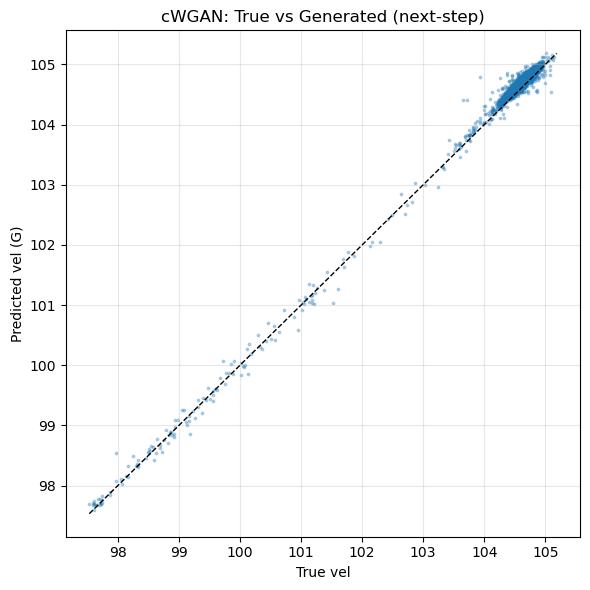

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_real_phys[:,0], y_hat_phys[:,0], s=3, alpha=0.3)
mn = min(y_real_phys.min(), y_hat_phys.min())
mx = max(y_real_phys.max(), y_hat_phys.max())
plt.plot([mn,mx],[mn,mx],'k--',linewidth=1)
plt.xlabel("True vel")
plt.ylabel("Predicted vel (G)")
plt.title("cWGAN: True vs Generated (next-step)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

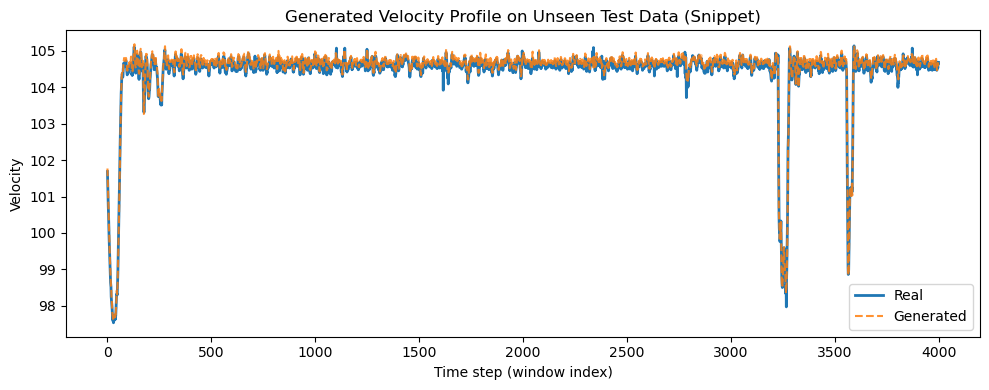

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

y_real_1d = y_real_phys[:,0]
y_pred_1d = y_hat_phys[:,0]

Nplot = min(4000, len(y_real_1d))  # adjust
plt.figure(figsize=(10,4))
plt.plot(y_real_1d[:Nplot], label="Real", linewidth=2)
plt.plot(y_pred_1d[:Nplot], label="Generated", linestyle="--", alpha=0.85)
plt.title("Generated Velocity Profile on Unseen Test Data (Snippet)")
plt.xlabel("Time step (window index)")
plt.ylabel("Velocity")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"y_pred_vs_real_snippet_{experiment_tag}.png", dpi=300, bbox_inches="tight")
plt.show()

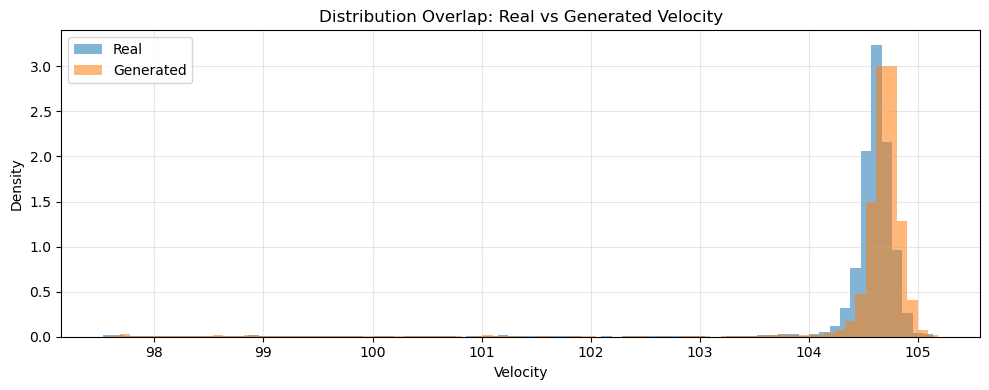

In [59]:
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,4))
plt.hist(y_real_1d, bins=80, density=True, alpha=0.55, label="Real")
plt.hist(y_pred_1d, bins=80, density=True, alpha=0.55, label="Generated")
plt.title("Distribution Overlap: Real vs Generated Velocity")
plt.xlabel("Velocity")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / f"dist_overlap_{experiment_tag}.png", dpi=300, bbox_inches="tight")
plt.show()

tau_perc(q=0.99) = 0.052037
Nominal FA P(|r_nom|>tau) = 0.0100 (target α=0.01)
Attack  exceed P(|r_atk|>tau) = 0.0091 (w.r.t nominal τ)


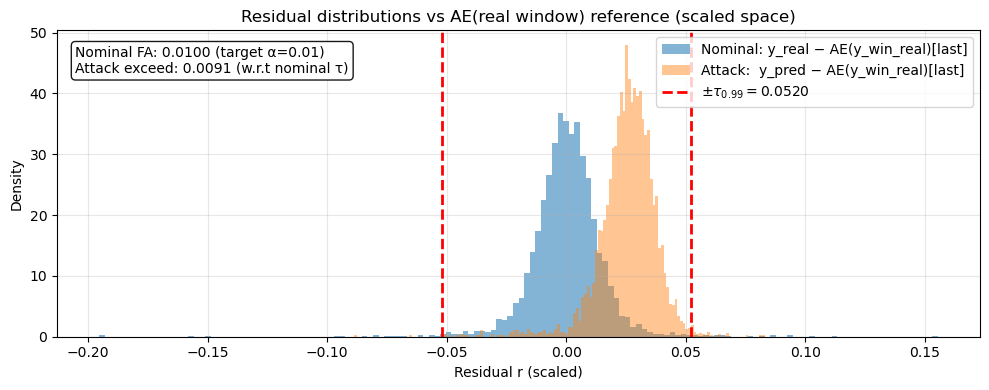

In [60]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
ae = ae.to(device).eval()
G = G.to(device).eval()

q = 0.99
alpha = 1 - q

@torch.no_grad()
def residuals_vs_AE_real(ae, test_loader, device, z_dim, mode="mc", k_samples=8):
    """
    Uses the REAL window (history yh + real next y_real) to compute AE reconstruction.
    Returns nominal residual r_nom = y_real - AE_last and attack residual r_atk = y_hat - AE_last.
    Everything in AE space (your scaled space).
    """
    r_nom_list, r_atk_list = [], []

    for Xh, yh, y_real in test_loader:
        yh = yh.to(device, non_blocking=True)        # (B,L,1) scaled
        y_real = y_real.to(device, non_blocking=True)  # (B,1) scaled
        if y_real.ndim == 1:
            y_real = y_real.unsqueeze(1)

        B, L, _ = yh.shape

        # ---- build REAL AE window: replace last element with y_real ----
        y_real_step = y_real.unsqueeze(-1)                      # (B,1,1)
        y_win_real  = torch.cat([yh[:, 1:, :], y_real_step], dim=1)  # (B,L,1)

        # ---- AE reconstruction of REAL window ----
        recon_real, _ = ae(y_win_real)                          # (B,L,1)
        AE_last = recon_real[:, -1, 0]                          # (B,)

        # ---- nominal residual: y_real - AE_last ----
        r_nom = (y_real[:, 0] - AE_last)                        # (B,)

        # ---- generate y_hat (attack prediction) ----
        if mode == "z0":
            z = torch.zeros(B, z_dim, device=device)
            y_hat = G(Xh.to(device, non_blocking=True), yh, z)  # (B,1)
        elif mode == "mc":
            preds = []
            Xh_dev = Xh.to(device, non_blocking=True)
            for _ in range(k_samples):
                z = torch.randn(B, z_dim, device=device)
                preds.append(G(Xh_dev, yh, z))
            y_hat = torch.mean(torch.stack(preds, dim=0), dim=0)  # (B,1)
        else:
            raise ValueError("mode must be 'z0' or 'mc'")

        # ---- attack residual: y_hat - AE_last ----
        r_atk = (y_hat[:, 0] - AE_last)                         # (B,)

        r_nom_list.append(r_nom.detach().cpu().numpy())
        r_atk_list.append(r_atk.detach().cpu().numpy())

    r_nom = np.concatenate(r_nom_list, axis=0)
    r_atk = np.concatenate(r_atk_list, axis=0)
    return r_nom, r_atk

# 1) compute residuals (scaled space)
r_nom, r_atk = residuals_vs_AE_real(ae, test_loader, device, z_dim, mode="mc", k_samples=8)

# 2) compute tau from nominal only
tau_perc = float(np.quantile(np.abs(r_nom), q))
fa_nom = float(np.mean(np.abs(r_nom) > tau_perc))
fa_atk = float(np.mean(np.abs(r_atk) > tau_perc))

print(f"tau_perc(q={q:.2f}) = {tau_perc:.6f}")
print(f"Nominal FA P(|r_nom|>tau) = {fa_nom:.4f} (target α={alpha:.2f})")
print(f"Attack  exceed P(|r_atk|>tau) = {fa_atk:.4f} (w.r.t nominal τ)")

# 3) plot both + ±tau (from nominal)
plt.figure(figsize=(10,4))
bins = 150

plt.hist(r_nom, bins=bins, density=True, alpha=0.55,
         label="Nominal: y_real − AE(y_win_real)[last]")
plt.hist(r_atk, bins=bins, density=True, alpha=0.45,
         label="Attack:  y_pred − AE(y_win_real)[last]")

plt.axvline(+tau_perc, color="r", linestyle="--", linewidth=2,
            label=rf"$\pm\tau_{{{q:.2f}}}={tau_perc:.4f}$")
plt.axvline(-tau_perc, color="r", linestyle="--", linewidth=2)

plt.title("Residual distributions vs AE(real window) reference (scaled space)")
plt.xlabel("Residual r (scaled)")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)

plt.text(
    0.02, 0.95,
    f"Nominal FA: {fa_nom:.4f} (target α={alpha:.2f})\n"
    f"Attack exceed: {fa_atk:.4f} (w.r.t nominal τ)",
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(fig_dir / "overlay_residuals_nominal_vs_attack_tau.png", dpi=300, bbox_inches="tight")
plt.show()


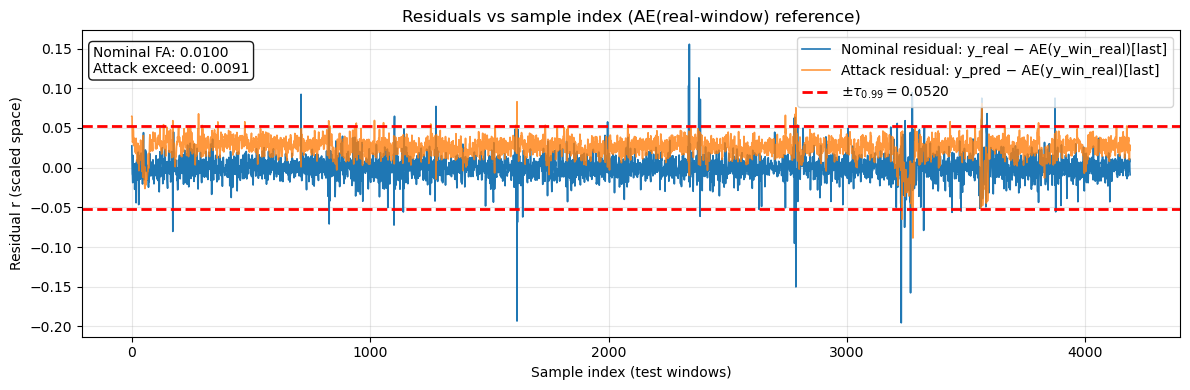

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

fig_dir = Path("figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# indices (aligned to test windows)
idx = np.arange(len(r_nom))

plt.figure(figsize=(12,4))

plt.plot(idx, r_nom, color="tab:blue", linewidth=1.2,
         label="Nominal residual: y_real − AE(y_win_real)[last]")
plt.plot(idx, r_atk, color="tab:orange", linewidth=1.2, alpha=0.8,
         label="Attack residual: y_pred − AE(y_win_real)[last]")

# ±tau from nominal
plt.axhline(+tau_perc, color="red", linestyle="--", linewidth=2,
            label=rf"$\pm\tau_{{{q:.2f}}}={tau_perc:.4f}$")
plt.axhline(-tau_perc, color="red", linestyle="--", linewidth=2)

plt.title("Residuals vs sample index (AE(real-window) reference)")
plt.xlabel("Sample index (test windows)")
plt.ylabel("Residual r (scaled space)")
plt.grid(True, alpha=0.3)

# annotate exceed rates
plt.text(
    0.01, 0.95,
    f"Nominal FA: {fa_nom:.4f}\nAttack exceed: {fa_atk:.4f}",
    transform=plt.gca().transAxes,
    va="top", ha="left",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.9)
)

plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(fig_dir / "residuals_vs_index_nominal_vs_attack.png",
            dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
#-------------------------CANet Implementation------------------------#

In [62]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

class CANet1ID(nn.Module):
    """
    Simple CANet-style per-ID model for 1 signal:
    LSTM -> hidden -> FC stack -> reconstruct current value
    """
    def __init__(self, hscale=10):
        super().__init__()
        self.hscale = hscale
        hidden_dim = 1 * hscale  # n_id * hscale, here n_id=1

        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=1, batch_first=True)

        # FC stack similar spirit to CANet (ELU)
        joint_dim = 1 * hscale
        self.fc1 = nn.Linear(joint_dim, max(4, joint_dim // 2))
        self.fc2 = nn.Linear(max(4, joint_dim // 2), 1)

    def forward(self, x_seq):
        """
        x_seq: (B, T, 1)
        returns: recon_next: (B, 1)
        """
        out, _ = self.lstm(x_seq)         # (B, T, H)
        h_last = out[:, -1, :]            # (B, H)
        z = F.elu(self.fc1(h_last))     # 
        #recon = F.elu(self.fc2(z))      # 
        recon = self.fc2(z)
        return recon

In [63]:
def make_windows_1d(y, seq_len=50, stride=1):
    """
    y: (N,) float array
    returns:
      X: (M, seq_len, 1)
      y_next: (M, 1)
    """
    y = np.asarray(y, dtype=np.float32).reshape(-1)
    X, y_next = [], []
    for t in range(seq_len, len(y), stride):
        X.append(y[t-seq_len:t])
        y_next.append(y[t])
    X = np.asarray(X, dtype=np.float32)[:, :, None]
    y_next = np.asarray(y_next, dtype=np.float32)[:, None]
    return X, y_next


In [64]:
from sklearn.preprocessing import StandardScaler

def fit_scaler(train_y):
    scaler = StandardScaler()
    scaler.fit(np.asarray(train_y, dtype=np.float32).reshape(-1,1))
    return scaler

@torch.no_grad()
def score_stream(model, loader, device):
    """
    Returns reconstruction squared error per sample window: (M,)
    """
    model.eval()
    errs = []
    for X, y_next in loader:
        X = X.to(device)
        y_next = y_next.to(device)
        recon = model(X)               # (B,1)
        e = (recon - y_next) ** 2      # (B,1)
        errs.append(e.squeeze(1).detach().cpu().numpy())
    return np.concatenate(errs, axis=0)

def train_model(model, train_loader, val_loader, device="cuda", lr=1e-3, epochs=20):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for ep in range(epochs):
        model.train()
        tr_loss = 0.0
        n = 0
        for X, y_next in train_loader:
            X = X.to(device)
            y_next = y_next.to(device)

            opt.zero_grad(set_to_none=True)
            recon = model(X)
            loss = loss_fn(recon, y_next)
            loss.backward()
            opt.step()

            tr_loss += loss.item() * X.size(0)
            n += X.size(0)

        # quick val loss
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            m = 0
            for Xv, yv in val_loader:
                Xv = Xv.to(device)
                yv = yv.to(device)
                rv = model(Xv)
                lv = loss_fn(rv, yv)
                val_loss += lv.item() * Xv.size(0)
                m += Xv.size(0)

        print(f"epoch {ep+1:03d}/{epochs}  train_mse={tr_loss/max(n,1):.6f}  val_mse={val_loss/max(m,1):.6f}")

def build_loader(X, y_next, batch_size=256, shuffle=False):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y_next))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=False, pin_memory=torch.cuda.is_available())


In [65]:
# Physical units (normal)
y_train_phys = df_train[target_feature].to_numpy(dtype=np.float32)
y_val_phys   = df_val[target_feature].to_numpy(dtype=np.float32)
y_test_phys  = df_test[target_feature].to_numpy(dtype=np.float32)
y_attack_phys = y_hat_phys.squeeze().astype(np.float32)

In [66]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler(feature_range=(0.0, 1.0))
mm.fit(y_train_phys.reshape(-1,1))  # train only

y_train_mm = mm.transform(y_train_phys.reshape(-1,1)).squeeze(1).astype(np.float32)
y_val_mm   = mm.transform(y_val_phys.reshape(-1,1)).squeeze(1).astype(np.float32)

# Make sure your normal test stream matches the attack stream sampling
# If you had done y_test = y_test[seq_len::5], do it here too:
y_test_mm_full = mm.transform(y_test_phys.reshape(-1,1)).squeeze(1).astype(np.float32)

# If you already know your attack stream corresponds to stride=5 sampling:
# y_test_mm = y_test_mm_full[seq_len::5]
# Otherwise:
y_test_mm = y_test_mm_full

y_attack_mm = mm.transform(y_attack_phys.reshape(-1,1)).squeeze(1).astype(np.float32)

print("MM ranges:")
print("train min/max:", y_train_mm.min(), y_train_mm.max())
print("val   min/max:", y_val_mm.min(), y_val_mm.max())
print("test  min/max:", y_test_mm.min(), y_test_mm.max())
print("atk   min/max:", y_attack_mm.min(), y_attack_mm.max())

MM ranges:
train min/max: 0.0 0.99999976
val   min/max: 0.25587296 0.9771426
test  min/max: 0.63238096 0.96952367
atk   min/max: 0.6549697 0.9636872


In [67]:
print("y_test:", y_test_mm.shape, "y_pred_test:", y_attack_mm.shape)

y_test: (20992,) y_pred_test: (4189,)


In [68]:
y_test_stride = y_test_mm[seq_len::5]  # or rebuild y_test stream the same way you built y_train_seq

In [69]:
print("y_test:", y_test_stride.shape, "y_pred_test:", y_attack_mm.shape)

y_test: (4189,) y_pred_test: (4189,)


In [70]:
device = "cuda" if torch.cuda.is_available() else "cpu"

seq_len = 50
stride  = 1
batch_size = 256
q_tau = 0.99  # try 0.99, 0.999, 0.9999 depending on strictness

# windows for normal
Xtr, ytr_next = make_windows_1d(y_train_mm, seq_len=seq_len, stride=stride)
Xva, yva_next = make_windows_1d(y_val_mm,   seq_len=seq_len, stride=stride)
Xte, yte_next = make_windows_1d(y_test_stride,  seq_len=seq_len, stride=stride)

# windows for attack stream (generated)
Xatk, yatk_next = make_windows_1d(y_attack_mm, seq_len=seq_len, stride=stride)

train_loader = build_loader(Xtr, ytr_next, batch_size=batch_size, shuffle=True)
val_loader   = build_loader(Xva, yva_next, batch_size=batch_size, shuffle=False)
testN_loader = build_loader(Xte, yte_next, batch_size=batch_size, shuffle=False)
testA_loader = build_loader(Xatk, yatk_next, batch_size=batch_size, shuffle=False)




In [71]:
# Xtr: (M, seq_len, 1), ytr_next: (M,1)
print("Xtr last vs y_next stats (train):",
      np.mean((Xtr[:, -1, 0] - ytr_next[:, 0])**2),
      np.mean(np.abs(Xtr[:, -1, 0] - ytr_next[:, 0])))

y_mean = ytr_next.mean()
baseline_mse = np.mean((ytr_next[:,0] - y_mean)**2)
print("baseline constant predictor MSE:", baseline_mse)

Xtr last vs y_next stats (train): 1.42806975e-05 0.002300996
baseline constant predictor MSE: 0.016626414


In [72]:
# 4) Train model on normal
model = CANet1ID(hscale=10)
train_model(model, train_loader, val_loader, device=device, lr=1e-3, epochs=20)

epoch 001/20  train_mse=0.056734  val_mse=0.000430
epoch 002/20  train_mse=0.000939  val_mse=0.000078
epoch 003/20  train_mse=0.000193  val_mse=0.000035
epoch 004/20  train_mse=0.000075  val_mse=0.000021
epoch 005/20  train_mse=0.000042  val_mse=0.000016
epoch 006/20  train_mse=0.000028  val_mse=0.000013
epoch 007/20  train_mse=0.000022  val_mse=0.000010
epoch 008/20  train_mse=0.000019  val_mse=0.000009
epoch 009/20  train_mse=0.000017  val_mse=0.000009
epoch 010/20  train_mse=0.000016  val_mse=0.000009
epoch 011/20  train_mse=0.000015  val_mse=0.000011
epoch 012/20  train_mse=0.000015  val_mse=0.000008
epoch 013/20  train_mse=0.000014  val_mse=0.000011
epoch 014/20  train_mse=0.000014  val_mse=0.000008
epoch 015/20  train_mse=0.000013  val_mse=0.000007
epoch 016/20  train_mse=0.000013  val_mse=0.000010
epoch 017/20  train_mse=0.000012  val_mse=0.000007
epoch 018/20  train_mse=0.000012  val_mse=0.000013
epoch 019/20  train_mse=0.000012  val_mse=0.000007
epoch 020/20  train_mse=0.00001

In [73]:
# 5) Threshold from NORMAL val errors
val_err = score_stream(model, val_loader, device=device)   # (M,)
# after computing val_err
print("val_err stats:")
print("  mean:", val_err.mean())
print("  std :", val_err.std())
print("  max :", val_err.max())
print("  p99 :", np.quantile(val_err, 0.99))
print("  p999:", np.quantile(val_err, 0.999))
print("  p9999:", np.quantile(val_err, 0.9999))

tau = float(np.quantile(val_err, q_tau))
print(f"tau (q={q_tau}) = {tau:.6f}")

val_err stats:
  mean: 6.149707e-06
  std : 4.4075703e-05
  max : 0.0034715624
  p99 : 6.353168e-05
  p999: 0.00048524755
  p9999: 0.0018952793
tau (q=0.99) = 0.000064


In [74]:
# 6) Evaluate
errN = score_stream(model, testN_loader, device=device)
errA = score_stream(model, testA_loader, device=device)

alarmN = (errN > tau).astype(np.int32)
alarmA = (errA > tau).astype(np.int32)

FPR = alarmN.mean()
TPR = alarmA.mean()
TNR_no_attack = 1 - FPR
TNR_attack = 1 - TPR

print(f"Normal test: FPR={FPR:.4f} (alarms={alarmN.sum()}/{len(alarmN)})")
print(f"Normal test: TNR={TNR_no_attack:.4f} ")
print(f"Attack  test: TPR={TPR:.4f} (alarms={alarmA.sum()}/{len(alarmA)})")
print(f"Attack  test: TNR={TNR_attack:.4f} ")

print(
    f"No-attack test (Accuracy / TNR): {TNR_no_attack:.4f} "
    f"(FPR={FPR:.4f}, alarms={alarmN.sum()}/{len(alarmN)})"
)

print(
    f"Stealth attack test (TPR / TNR): "
    f"{TPR:.4f} / {TNR_attack:.4f} "
    f"(alarms={alarmA.sum()}/{len(alarmA)})"
)



Normal test: FPR=0.2479 (alarms=1026/4139)
Normal test: TNR=0.7521 
Attack  test: TPR=0.2162 (alarms=895/4139)
Attack  test: TNR=0.7838 
No-attack test (Accuracy / TNR): 0.7521 (FPR=0.2479, alarms=1026/4139)
Stealth attack test (TPR / TNR): 0.2162 / 0.7838 (alarms=895/4139)


In [75]:
# Optional: also report mean scores
print(f"Mean err normal={errN.mean():.6f}, attack={errA.mean():.6f}")

print("val_err mean/max:", val_err.mean(), val_err.max())
print("val_err p99/p999/p9999:",
      np.quantile(val_err,0.99),
      np.quantile(val_err,0.999),
      np.quantile(val_err,0.9999))

Mean err normal=0.000139, attack=0.000136
val_err mean/max: 6.149707e-06 0.0034715624
val_err p99/p999/p9999: 6.353168e-05 0.00048524755 0.0018952793


In [76]:
@torch.no_grad()
def predict_next_series(model, y_stream, seq_len=50, stride=1, device="cuda", batch_size=256):
    """
    y_stream: (N,) scaled series
    returns:
      y_true_aligned: (M,)
      y_pred_aligned: (M,)
      idx_t: indices in original stream corresponding to these samples
    """
    X, y_next = make_windows_1d(y_stream, seq_len=seq_len, stride=stride)
    loader = build_loader(X, y_next, batch_size=batch_size, shuffle=False)

    model.eval()
    preds = []
    trues = []
    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        yhat = model(Xb)
        preds.append(yhat.squeeze(1).cpu().numpy())
        trues.append(yb.squeeze(1).cpu().numpy())

    y_pred = np.concatenate(preds)
    y_true = np.concatenate(trues)

    # indices where y_next comes from
    idx_t = np.arange(seq_len, len(y_stream), stride)[:len(y_true)]
    return y_true, y_pred, idx_t


import matplotlib.pyplot as plt

def plot_recon_with_alarms(y_true, y_pred, tau, title=""):
    e = (y_pred - y_true) ** 2
    alarms = (e > tau).astype(int)

    plt.figure(figsize=(12,4))
    plt.plot(y_true, label="True", linewidth=2)
    plt.plot(y_pred, "--", label="Reconstructed/Pred", linewidth=2, alpha=0.9)
    plt.title(title)
    plt.xlabel("Time (aligned)")
    plt.ylabel("Scaled value")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # alarm bar (like paper style)
    ax = plt.gca()
    ymin, ymax = ax.get_ylim()
    alarm_line = ymin + (ymax - ymin) * 0.05  # baseline
    height = (ymax - ymin) * 0.15
    ax.fill_between(np.arange(len(alarms)), alarm_line, alarm_line + height*alarms,
                    alpha=0.25, label="Alarm")
    plt.show()

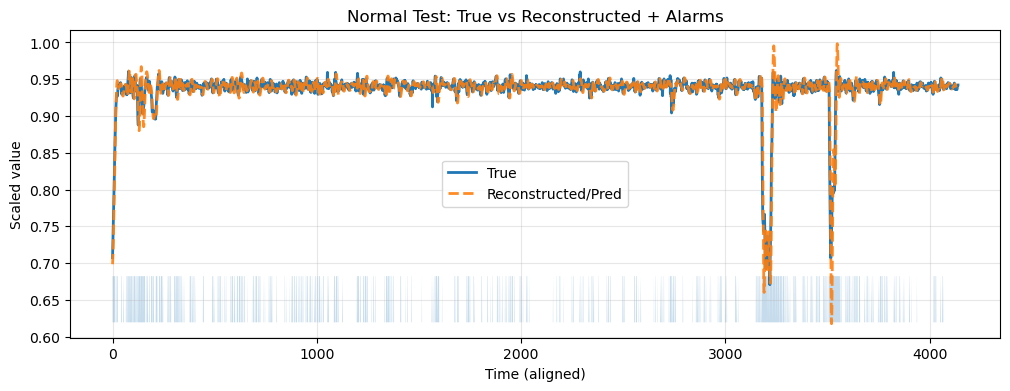

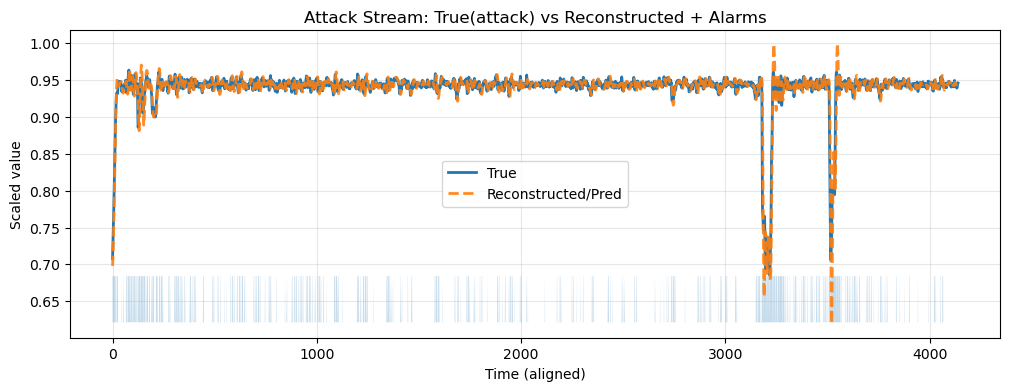

In [77]:
# after training + computing tau  y_test_stride.shape, "y_pred_test:", y_attack_mm.shape)
y_true_N, y_pred_N, _ = predict_next_series(model, y_test_stride, seq_len=seq_len, stride=stride, device=device, batch_size=batch_size)
y_true_A, y_pred_A, _ = predict_next_series(model, y_attack_mm, seq_len=seq_len, stride=stride, device=device, batch_size=batch_size)

plot_recon_with_alarms(y_true_N, y_pred_N, tau, title="Normal Test: True vs Reconstructed + Alarms")
plot_recon_with_alarms(y_true_A, y_pred_A, tau, title="Attack Stream: True(attack) vs Reconstructed + Alarms")